# 005. トークナイザと部分語分割

**Byte Pair Encoding・WordPiece・Unigram 言語モデル・SentencePiece — 語彙サイズと系列長のトレードオフ**
*Tokenizer and Subword Tokenization*

`theories/02_pretraining/005_tokenizer.ipynb`

## 1. 概要 / Overview

[001](../01_foundations/001_attention_mechanism.ipynb)〜[004](../01_foundations/004_normalization_and_activation.ipynb) では、条件比較を目的とした最小構成として文字レベル(character-level)の系列(`CharacterLevelTokenizer`)を前提にしてきた。しかし実際の大規模言語モデルは、文字でも単語でもなく **部分語(subword)** を入力の単位とする。本トピックでは、なぜ部分語が選ばれるのか(系列長・語彙サイズ・未知語のトレードオフ)を理論的に整理したうえで、代表的な部分語分割アルゴリズムである BPE(Byte Pair Encoding)・WordPiece・Unigram 言語モデル(Unigram Language Model)をスクラッチ実装し、アルゴリズムの一種と誤解されがちな SentencePiece の位置づけを明確にする。

英語・日本語・コードという性質の異なる 3 ドメインで語彙サイズを振った比較実験を行い、語彙サイズと圧縮効率(fertility)・系列長・計算量のトレードオフを定量的に検証する。トークナイザそのものの選定(どの方式・語彙サイズを 006 の事前学習で使うか)は本トピックでは行わず、006 で改めて選定する。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Gage, P. | A New Algorithm for Data Compression | The C Users Journal, Vol. 12, Issue 2, pp. 23–38, 1994 | https://dl.acm.org/doi/10.5555/177910.177914 |
| [2] | Sennrich, R., Haddow, B., Birch, A. | Neural Machine Translation of Rare Words with Subword Units | ACL 2016 (Volume 1: Long Papers), pp. 1715–1725 | https://aclanthology.org/P16-1162/ |
| [3] | Schuster, M., Nakajima, K. | Japanese and Korean Voice Search | ICASSP 2012, pp. 5149–5152 | https://research.google/pubs/japanese-and-korean-voice-search/ |
| [4] | Kudo, T. | Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates | ACL 2018 (Volume 1: Long Papers), pp. 66–75 | https://aclanthology.org/P18-1007/ |
| [5] | Kudo, T., Richardson, J. | SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing | EMNLP 2018: System Demonstrations, pp. 66–71 | https://aclanthology.org/D18-2012/ |
| [6] | Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., Sutskever, I. | Language Models are Unsupervised Multitask Learners | OpenAI, 2019 | https://d4mucfpksyws.cloudfront.net/better-language-models/language-models.pdf |
| [7] | Rust, P., Pfeiffer, J., Vulić, I., Ruder, S., Gurevych, I. | How Good is Your Tokenizer? On the Monolingual Performance of Multilingual Language Models | ACL-IJCNLP 2021 (Volume 1: Long Papers), pp. 3118–3135 | https://aclanthology.org/2021.acl-long.243/ |

本文中で各理論に言及する際は、対応する番号(例:「BPE [1, 2]」)を付す。

## 3. 理論 / Theory

**表記の約束**: 本節では、テキストを構成する最小単位を **文字(character)**、分割・符号化の最終的な出力単位を **トークン(token)** または **部分語(subword)/ 部分語片(piece)** と呼ぶ。文字列 $x$ に対する分割(セグメンテーション)を $\mathbf{x} = (x_1, \ldots, x_M)$($M$ 個の部分語の列、各 $x_i$ を連結すると $x$ に戻る)と書く。

### 3.1 動機・課題 / Motivation

**文字レベルの限界**: 001〜004 では、トークナイザそのものの性能を比較対象にしないという理由から、`CharacterLevelTokenizer` による文字レベルの系列を一貫して用いてきた(004 の実装方針を参照)。しかし文字レベルには本質的な限界がある。同じ量の情報を表すのに必要な系列長 $n$ が(部分語レベルと比べて)大きくなり、001 で導出した Scaled Dot-Product Attention の計算量 $O(n^2 d_{\text{model}})$、および順伝播ネットワーク(Feed-Forward Network)の計算量 $O(n \, d_{\text{model}}^2)$([002](../01_foundations/002_transformer_block.ipynb))がともに $n$ に対して増加する形で効いてくる(Attention は $n$ の 2 乗)。文字レベルの系列は、この $n$ を不必要に大きくしてしまう。

**単語レベルの限界**: 逆の極端である単語(word)を単位にすると、$n$ は大きく減るが、別の問題が生じる。

- **語彙サイズの爆発**: 活用形・複合語・固有名詞などを考慮すると、単語の異なり数は非常に大きくなる(実質的に上限がない)。
- **未知語(Out-of-Vocabulary)**: 学習コーパスに出現しなかった単語は語彙に存在せず、推論時に表現できない。
- **単語境界の不在**: 日本語・中国語のように、単語の境界が表層(スペースなど)に現れない言語では、そもそも「単語に分割する」こと自体が形態素解析などの追加処理を要する、自明ではない問題になる。

**部分語という中間解**: 部分語(subword)は、頻出する単語やその一部を 1 つのトークンとして扱いつつ、未知の単語は既知の断片(最悪の場合は 1 文字ずつ)に分解して表現する。これにより、語彙サイズを有限に固定したまま、任意の文字列を(未知語なしに、あるいは実用上ごくわずかな未知語で)表現できる。$n$ は文字レベルより小さく、単語レベルよりは大きい、中間的な値になる。3.7 節で、この中間性を語彙サイズと系列長のトレードオフとして定量化する。

#### 図 1: 手法の系譜 / Taxonomy of tokenization methods

以下は、本ノートブックで扱う手法どうしの位置づけを整理した図である。文字レベルと単語レベルを両端に置き、BPE・WordPiece・Unigram 言語モデルは「どの粒度で分割するか」を決める **アルゴリズム** として横軸上に並ぶ。一方 SentencePiece は同じ横軸上のどこかに位置する 1 手法ではなく、BPE または Unigram 言語モデルを **内部アルゴリズムとして選択できる実装** であり、軸に対して直交する(3.6 節で詳述)。

```mermaid
flowchart LR
    subgraph AXIS["分割の粒度(アルゴリズム)"]
        direction LR
        CHAR["文字レベル<br/>(character-level)<br/>001〜004 で使用"] --> BPE["BPE<br/>(Byte Pair Encoding)<br/>Gage 1994 / Sennrich+ 2016<br/>3.2, 3.3節"]
        BPE --> WP["WordPiece<br/>Schuster & Nakajima 2012<br/>3.4節(理論のみ)"]
        WP --> UNI["Unigram 言語モデル<br/>Kudo 2018<br/>3.5節"]
        UNI --> WORD["単語レベル<br/>(word-level)"]
    end
    SP["SentencePiece<br/>Kudo & Richardson 2018<br/>実装レイヤ(3.6節)<br/>内部で BPE または<br/>Unigram を選択できる"]
    SP -.選択.-> BPE
    SP -.選択.-> UNI
```

### 3.2 BPE(Byte Pair Encoding) / 3.2 BPE

**起源**: BPE はもともと Gage [1] が提案した汎用データ圧縮アルゴリズムであり、「最も頻出するバイト対を、コーパスに未出現の 1 バイトに置き換える」ことを繰り返すものだった。Sennrich et al. [2] は、この「頻出する対を 1 つの新しいシンボルにまとめる」という操作を、圧縮(バイト数を減らす)ではなく **語彙構築**(頻出する部分文字列をひとまとまりのトークンにする)に転用した。これが自然言語処理における BPE の起源である。

**学習(learning)**: 学習コーパスを何らかの初期シンボル列(3.3 節で 2 通りの初期化を扱う)に変換したのち、以下を反復する。

1. 隣接するシンボル対 $(s_1, s_2)$ ごとに、コーパス全体での出現頻度 $c(s_1, s_2)$ を数える。
2. 頻度が最大の対 $(s_1^\ast, s_2^\ast) = \arg\max_{(s_1, s_2)} c(s_1, s_2)$ を選び、新しいシンボル $s_1^\ast \oplus s_2^\ast$(文字列としての連結)としてコーパス中のすべての出現箇所をマージする。
3. このマージ規則 $(s_1^\ast, s_2^\ast)$ を **学習順に** 記録する。
4. 目標の語彙サイズ $V$ に達するか、それ以上マージできる対が無くなるまで 1〜3 を繰り返す。

**タイブレーク規則**: 手順 2 で頻度が同点の対が複数存在する場合、どれを選ぶかを決めるルールを固定しなければ、同じ入力から実行のたびに異なるマージ順序が生成されうる。本ノートブックでは、対 $(s_1, s_2)$ をタプルとして辞書式順序(まず $s_1$ を文字列として比較し、等しければ $s_2$ を比較する)で比較し、頻度が同点の場合は辞書式に最小の対を選ぶ。この規則を固定することが再現性(reproducibility)の根拠になる(4 節・7 節で詳述)。

**符号化(encoding)**: 学習で得られたマージ規則の列 $(s_1^{(1)}, s_2^{(1)}), (s_1^{(2)}, s_2^{(2)}), \ldots$ を、**学習順に**(規則の番号が小さいものを優先して)新しい文字列に適用する。具体的には、現在のシンボル列に含まれる隣接対のうち、マージ規則の中で最も早く学習されたものを毎回選んで 1 回マージし、適用可能な規則がなくなるまで繰り返す。

**学習と符号化の非対称性**: 学習は「その時点で最も頻度が高い対」を毎回選び直す(データ依存・貪欲(greedy)な手続き)のに対し、符号化は学習で確定した規則列を優先順位表として使うだけであり、符号化対象のテキストにおける頻度は一切参照しない。この非対称性(学習は頻度ベース、符号化は規則の学習順ベース)を混同すると、実装を誤る(例えば符号化時にも頻度で対を選んでしまう、など)。

**アルゴリズム(擬似コード)**:

```text
学習(learn_bpe):
入力: コーパス D、目標語彙サイズ V
出力: マージ規則列 merges、語彙 vocab

1: 初期シンボルでコーパスの各チャンクを分解し、頻度 freq を集計する
2: vocab ← 初期シンボル全体の集合
3: merges ← 空列
4: while |vocab| < V かつ マージ可能な対が存在する:
5:     すべての隣接対についてコーパス全体での頻度 c(s1, s2) を数える
6:     (s1*, s2*) ← 頻度最大の対(同点はタプルの辞書式順序で決定的にタイブレーク)
7:     コーパス中の (s1*, s2*) をすべて s1* ⊕ s2* にマージする
8:     merges.append((s1*, s2*));  vocab.add(s1* ⊕ s2*)
9: return merges, vocab

符号化(encode):
入力: 文字列 x、マージ規則列 merges(学習順)
出力: 部分語シンボル列

1: symbols ← x を初期シンボルに分解した列
2: while True:
3:     現在の symbols に含まれる隣接対のうち、merges の中で最も早く学習された対を探す
4:     見つからなければ break
5:     見つかった対のすべての出現箇所を 1 つのシンボルにマージする
6: return symbols
```

**計算量**: 素朴には、手順 5 でコーパス全体を毎回スキャンし直すと、1 回のマージあたり $O(N)$($N$: コーパスの総文字数)、目標語彙サイズ $V$ に達するまでに $O(V)$ 回のマージが必要なため、全体で $O(VN)$ になる。本実装では、各シンボル対がどのチャンクに含まれるかを追跡し(`pair_index`)、あるマージによって実際に変化したチャンクのみ差分更新することで、この毎回の全体スキャンを避けている(5 節参照)。

#### 図 2: BPE のマージ過程 / BPE merge process

小さな例(`"low", "lower", "lowest", "newer", "newest"` という 5 語からなるコーパス)で、マージによってシンボル列がどう成長するかを示す。初期状態では各語は 1 文字ずつのシンボル列であり、頻度最大の隣接対(この例では `e` と `r` の対、`newer` と `lower` に共通して出現する)から順にマージされていく。

```mermaid
flowchart TB
    S0["初期状態(1 文字ずつ)<br/>l o w<br/>l o w e r<br/>l o w e s t<br/>n e w e r<br/>n e w e s t"]
    S0 -->|"マージ 1: (e, r) → er<br/>(lower, newer に出現)"| S1["l o w<br/>l o w er<br/>l o w e s t<br/>n e w er<br/>n e w e s t"]
    S1 -->|"マージ 2: (e, s) → es<br/>(lowest, newest に出現)"| S2["l o w<br/>l o w er<br/>l o w es t<br/>n e w er<br/>n e w es t"]
    S2 -->|"マージ 3: (l, o) → lo"| S3["lo w<br/>lo w er<br/>lo w es t<br/>n e w er<br/>n e w es t"]
    S3 -->|"マージ 4: (lo, w) → low"| S4["low<br/>low er<br/>low es t<br/>n e w er<br/>n e w es t"]
    S4 -->|"以降、(es, t)→est,<br/>(n, e)→ne, (ne, w)→new<br/>と続く"| S5["low / low er / low est<br/>new er / new est"]
```

実験1で、実際のコーパスに対してこの過程を(30 個程度のマージ規則として)観察する。

### 3.3 バイトレベル BPE(byte-level BPE) / 3.3 Byte-level BPE

3.2 節の学習・符号化アルゴリズムは、「初期シンボルを何にするか」に依存する。ここには 2 つの選択肢がある。

- **文字レベル初期化**: 学習コーパスに出現した Unicode 文字をそのまま初期シンボルにする。学習コーパスに出現しなかった文字は語彙に存在しないため、推論時にその文字を含む入力があると表現できない(未知語、Out-of-Vocabulary)。
- **バイトレベル初期化(byte-level BPE)**: GPT-2 [6] が採用した方式で、初期シンボルを Unicode 文字ではなく **UTF-8 の 256 バイト値** にする。任意の Unicode 文字列は UTF-8 バイト列として一意に表現できるため、初期語彙が「バイト値 0〜255 のすべて」を含む限り、コーパスに一度も出現しなかった文字(絵文字、稀な漢字など)であっても、必ずいずれかのバイトの組み合わせとして表現できる。これにより、**未知語が原理的に発生しなくなる**(実験3で検証する)。

**トレードオフ**: バイトレベル初期化には代償がある。ASCII 文字(英数字など)は UTF-8 で 1 バイトだが、日本語の文字の多くは UTF-8 で **3 バイト** を占める。文字レベル初期化であれば、頻出する日本語の 1 文字は最初から 1 個のシンボル(1 トークン)として扱えるのに対し、バイトレベル初期化ではその 1 文字を表すために 3 バイトのシンボルを毎回マージして 1 個のシンボルに統合し直す必要がある。このコストが実際にどれだけの語彙(マージ回数)を消費しているかは実験4で測定する。

ただしこの代償の大きさは語彙サイズに依存する点に注意が必要である。目標語彙サイズが十分に大きければ、バイトレベル初期化であってもマージによって頻出する日本語文字を 1 トークンに統合しきれる。一方、文字レベル初期化の側にも見落とされがちな制約がある。日本語のようにユニーク文字数が多い言語では、目標語彙サイズがそのユニーク文字数を下回る間、文字レベル初期化は **マージを 1 回も行えない**(初期シンボルの数だけで既に目標語彙サイズに達してしまうため)。したがって「バイトレベル BPE は日本語で UTF-8 の 3 バイト表現のコストを負う」という主張は、低語彙サイズ域で無条件に成り立つものではなく、両者がともにマージの余地を持つ比較可能な語彙サイズ域でどちらが有利かという、**語彙サイズに依存したトレードオフ** として検証する必要がある(実験4)。「バイトレベルは常に優れている」「文字レベルは常に優れている」のいずれの単純な結論も、実験4の結果次第では成り立たない可能性がある。

### 3.4 WordPiece / 3.4 WordPiece

WordPiece [3] は、Google が音声認識(日本語・韓国語の音声検索)のために提案した部分語分割アルゴリズムで、後に BERT 系列のモデルで広く使われた。学習の反復構造は BPE(3.2 節)と同じ(隣接対を反復的にマージし、目標語彙サイズに達したら終了)だが、**どの対をマージするかを選ぶ基準** が異なる。

BPE がペア $(A, B)$ の生の出現頻度をスコアとするのに対し($\mathrm{score}_{\text{BPE}}(A, B) = \mathrm{freq}(AB)$)、WordPiece は

$$
\mathrm{score}_{\text{WordPiece}}(A, B) = \frac{\mathrm{freq}(AB)}{\mathrm{freq}(A) \cdot \mathrm{freq}(B)}
$$

を用いる。これは点別相互情報量(pointwise mutual information)に類似した量であり、$A$ と $B$ それぞれの出現頻度に対して $AB$ の共起が「どれだけ偶然の水準を上回るか」を測る。単に頻出するというだけでなく、$A$ と $B$ が互いに強く結びついているペアを優先してマージする点が BPE との違いである(直感的には、コーパス中の尤度の増加分を近似する基準になっている)。

**実装方針の注記**: 本ノートブックでは、WordPiece は理論の説明にとどめ、スクラッチ実装は行わない。学習の反復構造は BPE と共通であり($\mathrm{score}$ 関数だけを差し替えれば得られる)、本トピックが重視する「BPE(構築手続き)と Unigram 言語モデル(確率モデル)の対比」(3.5 節)という観点からは、WordPiece は BPE と同じ「構築手続き」側に位置づけられる派生形であるため、実装による追加の学びが少ないと判断した。

### 3.5 Unigram 言語モデル(Unigram Language Model) / 3.5 Unigram Language Model

**BPE との本質的な違い**: BPE(および WordPiece)は「隣接対を反復的にマージする」という **構築手続き(procedure)** であり、それ自体は確率モデルではない。これに対し Unigram 言語モデル [4] は、部分語の列に対する明示的な **生成確率モデル** として定式化される。この対比 ――「BPE は手続き、Unigram 言語モデルはモデル」―― が両者の本質的な違いである。

**定式化**: 語彙 $V$ の各部分語(piece)$v \in V$ に生起確率 $p(v)$ が割り当てられているとする($\sum_{v \in V} p(v) = 1$)。文字列 $x$ の分割 $\mathbf{x} = (x_1, \ldots, x_M)$($x_i \in V$、$x_1 \oplus \cdots \oplus x_M = x$)に対して、各部分語が独立に生成されると仮定し、

$$
P(\mathbf{x}) = \prod_{i=1}^{M} p(x_i)
$$

と定義する。$M$ は分割 $\mathbf{x}$ に含まれる部分語の個数(分割によって異なりうる)。

**分割の非一意性と最尤分割**: 同じ文字列 $x$ に対して、複数の分割 $\mathbf{x}$ が存在しうる(例:`"unlock"` は `["un", "lock"]` とも `["u", "n", "lock"]` とも分割できる)。Unigram 言語モデルは、その中で $P(\mathbf{x})$ を最大化する分割(最尤分割)を採用する。

$$
\hat{\mathbf{x}} = \arg\max_{\mathbf{x} : x_1 \oplus \cdots \oplus x_M = x} P(\mathbf{x}) = \arg\max_{\mathbf{x}} \sum_{i=1}^{M} \log p(x_i)
$$

これは、文字位置を頂点、語彙に含まれる部分語を辺(重み $\log p(x_i)$)とする有向非巡回グラフ(分割格子、lattice)の上で最長経路(対数確率の和が最大の経路)を求める問題であり、**Viterbi アルゴリズム**(動的計画法)で厳密に解ける。本ノートブックでは、この Viterbi 最尤分割(`viterbi_segment`)をスクラッチ実装する。

**語彙学習(EM ベースの反復的縮小)**: 学習コーパスから、大きな候補語彙(頻出する部分文字列の集合)を初期状態として用意し、以下を反復する。

1. 現在の語彙・確率のもとで、EM アルゴリズム(期待値最大化法)により各部分語の確率 $p(v)$ を推定する(E ステップ: 各文の最尤分割、または分割の期待値を計算し、M ステップ: 部分語の出現期待頻度から確率を再推定する)。
2. 各部分語 $v$ について、$v$ を語彙から除いた場合にコーパス全体の対数尤度がどれだけ減少するか(その部分語の「効用」)を評価する。
3. 効用の低い部分語から一定割合(shrinking factor)を語彙から削減する。
4. 目標語彙サイズに達するまで 1〜3 を繰り返す。

本ノートブックでは、この語彙学習は sentencepiece に委ね(4 節・実装方針を参照)、Viterbi 最尤分割のみをスクラッチ実装する。

**Subword regularization**: Kudo [4] は、学習時に常に最尤分割(1 通り)だけを使うのではなく、$P(\mathbf{x})$ に応じて複数の分割候補を確率的にサンプリングして学習データに使う **subword regularization** を提案した。同じ単語が学習中に複数の分割で出現することが、部分語の境界の揺らぎに対するモデルの頑健性を高める一種のデータ拡張として働く。本ノートブックは分割(推論)のみを扱い、モデルの学習は行わないため、subword regularization 自体は実装しない。

#### 図 3: Unigram 言語モデルの分割格子(lattice)と Viterbi 経路

文字列 `"unlock"` を例に、語彙に含まれる部分語ごとに 1 本の辺を持つ分割格子を示す。各辺の重みは対数確率 $\log p(v)$(値が大きい = 確率が高い)であり、Viterbi アルゴリズムは頂点 0(先頭)から頂点 6(末尾)までの重みの和が最大になる経路を動的計画法で求める。図中では、`["un", "lock"]` という分割(太字矢印)が `["u", "n", "lock"]` より高い対数確率の和を持ち、最尤分割として選ばれる例を示す。

```mermaid
flowchart LR
    P0(("0"))
    P1(("1<br/>u"))
    P2(("2<br/>un"))
    P3(("3<br/>unl"))
    P4(("4<br/>unlo"))
    P5(("5<br/>unloc"))
    P6(("6<br/>unlock"))

    P0 -->|"u<br/>log p=-3.1"| P1
    P0 ==>|"un<br/>log p=-2.0"| P2
    P1 -->|"n<br/>log p=-2.8"| P2
    P2 ==>|"lock<br/>log p=-2.5"| P6
    P2 -->|"l<br/>log p=-3.5"| P3
    P3 -->|"o<br/>log p=-2.9"| P4
    P4 -->|"c<br/>log p=-3.3"| P5
    P5 -->|"k<br/>log p=-2.7"| P6

    classDef best stroke:#e63946,stroke-width:3px;
    class P0,P2,P6 best;
```

太字(⇒)の経路が `["un", "lock"]`(対数確率の和 $-2.0 + (-2.5) = -4.5$)であり、細字の経路をすべて辿る `["u", "n", "lock"]` の和($-3.1 + (-2.8) + (-2.5) = -8.4$)より大きい。実験6で、この Viterbi 分割の実装が sentencepiece 自身の分割結果と一致することを検証する。

### 3.6 SentencePiece / 3.6 SentencePiece

**SentencePiece はアルゴリズムではなく実装である** [5]。3.2〜3.5 節で見た BPE や Unigram 言語モデルが「部分語をどう選ぶか」を定めるアルゴリズムであるのに対し、SentencePiece は、内部アルゴリズムとして BPE と Unigram 言語モデルの **どちらでも選択できる**、学習・符号化・復号を一貫して行うためのソフトウェア実装である。図1 で SentencePiece をアルゴリズムの系譜(横軸)に対して直交する位置に置いたのはこのためである。

SentencePiece のもう 1 つの特徴は、**生のテキストを直接扱い、事前分割(pre-tokenization)を必要としない設計** にある。3.2 節で実装する自作の BPE は、`chunk_split_mode`(空白の直前で事前分割するか、しないか)を明示的に指定する必要があり、この選択自体が言語依存の問題を引き起こす(3.7 節・実験5で検証する、日本語では空白による事前分割が機能しないという問題)。これに対し SentencePiece は、空白を含むテキストをあらかじめ単語に分割することを前提とせず、**空白そのものを語彙上のシンボルの 1 つ** として扱う。具体的には、入力テキスト中の空白文字を`▁`(U+2581、下線に似た専用の記号)に置き換えてから分割する。分割結果の部分語を単純に連結し、`▁`を空白に戻すだけで元のテキストを **完全に復元(lossless detokenization)** できる。

自作の BPE も、事前分割(3.2 節の`pretokenize`)の`whitespace`モードで空白をチャンクの先頭に保持する設計にしたことにより、符号化結果を単純に連結するだけで元のテキストを完全に復元できる(5.1 節の可逆性の検証を参照)。この点では SentencePiece の`▁`による可逆性と実質的に同じ性質を持つ(GPT-2 のバイトレベル BPE [6] も同じ「空白をチャンク先頭に含める」方式を採用している)。両者の違いは可逆性の **有無** ではなく、その **実現方法** にある。SentencePiece は`▁`という明示的な語彙記号を導入することで、事前分割の要否そのものをアルゴリズムから切り離している(利用者に`chunk_split_mode`のような選択を要求しない)のに対し、自作の BPE の可逆性は`chunk_split_mode="whitespace"`という特定の事前分割方式を選んだ場合に限られる(`chunk_split_mode="none"`は複数行にわたるテキストで改行が失われるため可逆ではない、5.1 節を参照)。

SentencePiece が事前分割の要否をアルゴリズムから切り離せるのは、そもそも事前分割の有無が圧縮効率(fertility)にどれだけ影響するかという点と無関係ではないはずである。事前分割の方式が fertility にどの程度影響するかは実験5で測定する。

### 3.7 語彙サイズと系列長のトレードオフ / Vocabulary size vs. sequence length

3.1 節で述べた通り、部分語は文字レベルと単語レベルの中間解であり、語彙サイズ $V$ の選び方によってこの中間性の度合いが変わる。本節では、このトレードオフをモデルのパラメータ数・計算量という観点から定式化する。

**埋め込み行列のパラメータ数**: トークン埋め込み(および出力の線形写像、多くの実装で重み共有される)のパラメータ数は

$$
\#\text{params}_{\text{embed}} = V \times d_{\text{model}}
$$

であり、$V$ に **比例して線形に増加** する($d_{\text{model}}$: モデルの隠れ次元、[001](../01_foundations/001_attention_mechanism.ipynb) の記法)。

**系列長に依存する計算量**: [001](../01_foundations/001_attention_mechanism.ipynb) で導出した Scaled Dot-Product Attention の計算量は系列長 $n$ に対して $O(n^2 d_{\text{model}})$、[002](../01_foundations/002_transformer_block.ipynb) の順伝播ネットワークの計算量は $O(n \, d_{\text{model}}^2)$ である。$V$ を大きくして 1 トークンあたりの表現力を上げる(圧縮効率を高める)ほど、同じ量の文字列を表すのに必要なトークン数 $n$ は **減少** する。

**fertility(1 文字あたりのトークン数)**: この圧縮効率を定量化する指標として、fertility を

$$
\mathrm{fertility} = \frac{(\text{トークン数})}{(\text{文字数})}
$$

と定義する(Rust et al. [7] の定義に基づく)。fertility が小さいほど、同じ文字数のテキストをより少ないトークンで表現できている。

**単語ではなく文字を分母にする理由**: Rust et al. [7] を含む多くの先行研究では、fertility を「1 単語あたりのトークン数」として定義することが多い。しかし本リポジトリは日本語(単語境界が表層に現れない言語、3.1 節)を扱うため、そもそも「単語数」を言語に依存せず一貫して数える手段がない。そこで本ノートブックでは、分母を単語数ではなく **文字数** に統一する。これにより、英語・日本語・コードという性質の異なるドメイン間でも同じ定義で比較できる。

**トレードオフの構造**: 固定量の文字列(文字数 $C$)を処理する際の系列長は $n \approx C \times \mathrm{fertility}(V)$ と書ける。$V$ を増やすと $\mathrm{fertility}(V)$ は減少する(圧縮効率が上がる)ため $n$ は減り、Attention・順伝播ネットワークの計算量は下がる。しかし埋め込み行列のパラメータ数 $V \times d_{\text{model}}$ は増え続ける。したがって、

- $V$ が小さい領域では、$V$ を増やすことで系列長由来の計算量が大きく減る一方、埋め込みパラメータの増加は緩やか(直線的)である。
- $V$ が大きい領域では、fertility の減少が鈍化する(3.2 節の圧縮効率が収穫逓減する、実験2で検証する)一方、埋め込みパラメータは増え続ける。

このため、埋め込みパラメータと系列長由来の計算量の和を最小化する $V$ が(少なくとも数値的には)存在しうる。ただし、fertility(V) の関数形はドメイン(英語・日本語・コード)によって大きく異なるため、最適点の位置もドメインに依存する。実験7で、実験2で得た実測の fertility を用いてこれを数値的に確認する。

## 4. 実装方針 / Implementation Policy

CLAUDE.md のコーディング規約は、トークナイザの学習(BPE の学習など)を手段として使う場合は`tokenizers`などの既存ライブラリを活用してよいと述べている。しかし **本トピックはトークナイザそのものを主題とする** ため、この例外規定は適用せず、BPE の学習・符号化と Unigram 言語モデルの Viterbi 最尤分割はスクラッチ実装する。

| 機能 | 配置場所 | 実装/委譲 |
|---|---|---|
| BPE の学習(`learn_bpe`)・符号化(`BPETokenizer`)、バイトレベル初期化 | `src/data/tokenizer.py` | スクラッチ実装 |
| 事前分割(`pretokenize`、`chunk_split_mode`) | `src/data/tokenizer.py` | スクラッチ実装 |
| Unigram 言語モデルの Viterbi 最尤分割(`viterbi_segment`) | `src/data/tokenizer.py` | スクラッチ実装 |
| Unigram 言語モデルの語彙学習(EM ベースの反復的縮小)、`UnigramTokenizer`・`train_unigram_model` | `src/data/tokenizer.py` | **sentencepiece に委譲**(理由は下記) |
| WordPiece | (実装なし、3.4 節で理論のみ) | — |
| 英語・日本語・コードコーパスの取得(`load_tiny_shakespeare`・`load_japanese_corpus`・`load_code_corpus`) | `src/data/text.py` | スクラッチ実装(日本語は Wikipedia API、コードは本リポジトリ自身の`src/`) |
| fertility・未知語率・チャンク長分布・分割一致率の計算 | `src/utils/statistics.py` | スクラッチ実装 |
| 語彙サイズ×fertility 曲線、チャンク長のグループ棒グラフ、語彙サイズと計算量のトレードオフ図 | `src/utils/visualization.py` | スクラッチ実装(`plot_grouped_bar`・`plot_dual_axis_curves`を新規追加) |
| BPE と Unigram 言語モデルの分割比較・可視化 | 本ノートブック(実験セル) | ノートブック内に直接記述 |

**Unigram 言語モデルの語彙学習のみをライブラリに委ねる理由**: 3.5 節で述べた通り、語彙学習は EM アルゴリズムによる反復的なパラメータ推定と語彙削減からなる、実装がそれ自体で 1 つのトピックになりうる手続きである。本トピックが検証したいのは「Unigram 言語モデルが与えられた語彙のもとでどう分割を決めるか」(Viterbi 最尤分割というアルゴリズム)であり、「語彙をどう学習するか」ではない。そこで語彙学習は sentencepiece に委譲し、**その語彙(部分語ごとの対数確率)を受け取って最尤分割を求める部分だけをスクラッチ実装する**。この設計にはもう 1 つ利点がある。sentencepiece 自身も内部で Viterbi 最尤分割を行っており(学習した語彙で`encode`すると最尤分割が返る)、自作の`viterbi_segment`の出力と sentencepiece 自身の出力を **同一の語彙に対して** 比較できる。両者が一致すれば、それ自体が自作実装の正しさの証拠になる(実験6)。

**自作 BPE の可逆性についての注記**: 3.6 節で述べた通り、SentencePiece は空白を`▁`として扱うことで可逆な復号を実現する。本ノートブックの自作 BPE も、事前分割(`pretokenize`)の`chunk_split_mode="whitespace"`で空白をチャンクの先頭に保持する設計にしたことで、符号化結果を単純に連結するだけで元のテキストを完全に復元できる(可逆性の検証を 5.1 節に置く)。ただしこの可逆性は`chunk_split_mode="whitespace"`を選んだ場合に限られ、`chunk_split_mode="none"`は複数行にわたるテキストで改行が失われるため可逆ではない(実装上の単純化、3.2 節の`pretokenize`の docstring を参照)。

## 5. 実装 / Implementation

`src/` から必要な関数・クラスを import して使う。以下のセットアップセルは 004 までと同様、Google Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。

In [1]:
# 環境セットアップ(Google Colab)
# Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

Cloning into 'ai-theories'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 262 (delta 129), reused 210 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (262/262), 3.01 MiB | 10.03 MiB/s, done.
Resolving deltas: 100% (129/129), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 65.5 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 41 packages in 292ms
Prepared 27 packages in 47.96s
Uninstalled 12 packages in 1.07s
Installed 27 packages in 507ms
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.5.6
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.29.7
 + filelock==3.32.2
 - fsspec==2025.3.0
 + fsspec==2026.7.0
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 - numpy==2.0.2
 + numpy==2.5.2
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nv

In [2]:
# `from src...` の絶対 import が通るように、リポジトリルートを sys.path に追加する。
# (ノートブックを theories/02_pretraining/ から直接開いた場合の保険)
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # theories/02_pretraining/ から起動した場合
    ROOT = ROOT.parents[1]
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repository root:", ROOT)

repository root: /content/ai-theories


In [3]:
import time

from src.data import (
    BPETokenizer,
    learn_bpe,
    load_code_corpus,
    load_japanese_corpus,
    load_tiny_shakespeare,
    pretokenize,
    train_unigram_model,
)
from src.utils import (
    compute_character_coverage,
    compute_chunk_length_statistics,
    compute_exact_match_rate,
    compute_fertility,
    compute_segmentation_agreement_rate,
    compute_unknown_rate,
    plot_dual_axis_curves,
    plot_grouped_bar,
)

### 5.1 可逆性の検証

事前分割(`pretokenize`)の`chunk_split_mode="whitespace"`は、空白の直前で分割し空白を次のチャンクの先頭に含める(3.2 節)。この結果、`BPETokenizer.encode()`の出力トークンを連結する(`byte_level=True`の場合は`BPETokenizer.decode()`で UTF-8 バイト列からデコードし直す)と、元のテキストが過不足なく復元できるはずである。`chunk_split_mode="none"`は改行のみ保持しないため、改行を含まないテキストでは同様に復元できるが、複数行にわたるテキストでは復元できない(`pretokenize`の docstring を参照)。この性質を、`byte_level`の真偽 × `chunk_split_mode`の 2 通り、計 4 通りの組み合わせで確認する。`byte_level=True`の検証をより強くするため、UTF-8 で 1 バイトの英語のみのサンプルに加え、3 バイトの日本語・4 バイトの絵文字を含むサンプルでも同様に確認する。

In [4]:
# 可逆性の検証: BPETokenizer.encode() の出力を連結(byte_level=True の場合は decode())
# すると、入力テキストが復元できるか。改行を含まない文字列を使う
# (chunk_split_mode="none" は改行を保持しないため、改行を含む文字列では
# そもそも復元できないという 5.1 節で述べた既知の制約を切り分けるため)。
# byte_level=True の検証を強めるため、UTF-8 で 1 バイトの英語のみに加え、
# 3 バイトの日本語・4 バイトの絵文字を含むサンプルでも確認する。
roundtrip_samples = {
    "英語のみ": "  The quick, brown fox—jumps over the lazy dog!   Multiple   spaces here.  ",
    "日本語を含む": "  これは  日本語を含む   テスト文です。UTF-8で3バイトの文字を含む。  ",
    "絵文字を含む": "  Multiple emoji here: 😀🎉🚀 and more spaces after.  ",
}

for label, sample in roundtrip_samples.items():
    print(f"=== {label} ===")
    for byte_level in [False, True]:
        for mode in ["whitespace", "none"]:
            tokenizer = learn_bpe(
                sample, vocab_size=300, byte_level=byte_level, chunk_split_mode=mode
            )
            tokens = tokenizer.encode(sample)
            reconstructed = tokenizer.decode(tokens)
            match = reconstructed == sample
            print(f"  byte_level={byte_level!s:<5} chunk_split_mode={mode:<10} 復元一致={match}")
            assert match, (
                f"復元に失敗した: サンプル={label!r}, byte_level={byte_level}, mode={mode}"
            )

=== 英語のみ ===
  byte_level=False chunk_split_mode=whitespace 復元一致=True
  byte_level=False chunk_split_mode=none       復元一致=True
  byte_level=True  chunk_split_mode=whitespace 復元一致=True
  byte_level=True  chunk_split_mode=none       復元一致=True
=== 日本語を含む ===
  byte_level=False chunk_split_mode=whitespace 復元一致=True
  byte_level=False chunk_split_mode=none       復元一致=True
  byte_level=True  chunk_split_mode=whitespace 復元一致=True
  byte_level=True  chunk_split_mode=none       復元一致=True
=== 絵文字を含む ===
  byte_level=False chunk_split_mode=whitespace 復元一致=True
  byte_level=False chunk_split_mode=none       復元一致=True
  byte_level=True  chunk_split_mode=whitespace 復元一致=True
  byte_level=True  chunk_split_mode=none       復元一致=True


### 5.2 コーパスの取得

英語(`load_tiny_shakespeare`、004 と共通)・日本語(`load_japanese_corpus`、日本語版 Wikipedia の記事本文)・コード(`load_code_corpus`、本リポジトリ自身の`src/`配下の Python ソースコード)の 3 ドメインを取得する。

**日本語コーパスの出典とライセンス**: 日本語ドメインは、フリー百科事典『ウィキペディア(Wikipedia)』日本語版(https://ja.wikipedia.org/)の記事本文を、クリエイティブ・コモンズ 表示-継承 4.0 国際(CC BY-SA 4.0)ライセンスの下で使用する。記事本文は編集され続けるため、記事タイトルだけでは実行のたびに異なる文字列になりうる。そこで`load_japanese_corpus`は、記事タイトルと **リビジョン ID(特定時点の版を指す ID)を固定した組**(`src/data/text.py`の`_JAPANESE_WIKIPEDIA_REVISIONS`)から Wikimedia API(`action=parse`、`oldid`でリビジョンを指定)を用いて取得することで、実行時点によらず同一の入力を得る(6 節・実験の再現性についての注記も参照)。取得は Wikimedia API への複数回のリクエストを伴うため、初回の実行に数分かかることがある(2 回目以降はキャッシュから読むため一瞬で終わる)。

In [5]:
CACHE_DIR = ROOT / ".cache" / "tokenizer"

t0 = time.time()
corpus_en = load_tiny_shakespeare(CACHE_DIR)
corpus_ja = load_japanese_corpus(CACHE_DIR)
corpus_code = load_code_corpus(ROOT)
print(f"取得時間: {time.time() - t0:.1f} 秒")

for name, corpus in [("English", corpus_en), ("Japanese", corpus_ja), ("Code", corpus_code)]:
    print(f"{name}: {len(corpus):,} 文字")
    print(repr(corpus[:80]))
    print()

取得時間: 251.3 秒
English: 1,115,394 文字
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.'

Japanese: 654,854 文字
'日本国（にほんこく、にっぽん-）、または日本（にほん、にっぽん）は、東アジアに位置する立憲君主制国家。面積は 377,975.64 km2（平方キロメートル）、'

Code: 102,057 文字
'"""`theories/`・`apps/` の双方から再利用する共通モジュール。"""\n\n"""theories/・apps/ から再利用するデータ処理ユーテ'



In [6]:
# 3 ドメインを同一サイズの学習用・ホールドアウト用に切り出す(ドメイン間の公平な比較のため)。
# コードコーパスが最も小さいため、その範囲に収まるサイズに揃える。
TRAIN_SIZE = 60_000
HOLDOUT_SIZE = 15_000

corpora = {"English": corpus_en, "Japanese": corpus_ja, "Code": corpus_code}
train_texts = {name: text[:TRAIN_SIZE] for name, text in corpora.items()}
holdout_texts = {
    name: text[TRAIN_SIZE : TRAIN_SIZE + HOLDOUT_SIZE] for name, text in corpora.items()
}

for name, text in corpora.items():
    assert len(text) >= TRAIN_SIZE + HOLDOUT_SIZE, f"{name} コーパスが小さすぎる: {len(text)} 文字"
print("学習・ホールドアウトの切り出しに成功")

学習・ホールドアウトの切り出しに成功


## 6. 実験 / Experiments

以下の実験はすべて Google Colab 無料枠(CPU で十分実行できる規模。学習を伴う実験は 001〜004 と異なり GPU を必要としない)で実行可能な規模で構成する。

**再現性についての注記**: 001〜004 の実験は、学習過程に乱数(重みの初期化、ミニバッチのサンプリングなど)を含むため、複数シードでの反復によって結果の安定性を確認していた。本トピックの BPE の学習・符号化、および Unigram 言語モデルの Viterbi 最尤分割は、乱数を一切使わない **決定的(deterministic)** な処理である(3.2 節のタイブレーク規則、3.5 節の動的計画法)。したがって複数シードでの反復は行わない。

ただし、アルゴリズムが決定的であっても **入力コーパスが実行のたびに変化すれば結果は再現しない**。したがって、本トピックの再現性は入力・アルゴリズムの両面から成り立つ。

- **アルゴリズム面**: タイブレーク規則を固定していること(3.2 節: 頻度同点時は対のタプルの辞書式順序で一意に決定する)。この規則を固定しない実装では、同じ入力コーパスからでも実行のたびに異なるマージ順序が得られうる。
- **入力面**: 英語(Tiny Shakespeare、`load_tiny_shakespeare`)は固定の配布ファイルであるため不変である。日本語(`load_japanese_corpus`)は、5.2 節で述べた通りタイトルとリビジョン ID の両方を固定して取得するため、記事本文が今後編集されても本ノートブックが取得するコーパスは変わらない。**コード(本リポジトリ自身の`src/`、`load_code_corpus`)はこの 2 つとは異なり不変ではない**。`src/`は 006 以降のトピック追加のたびに拡張され、`load_code_corpus`はファイルをパスの辞書順に連結するため、新しいファイルが加わると`TRAIN_SIZE`で切り出す先頭部分の内容が将来のコミットで変化しうる。コードドメインの役割は「空白・記号が多い第 3 のドメイン」として英語・日本語との質的な対比を得ることにあり、絶対値の長期的な再現を目的としていないため、この不変性の欠如は許容する。

以上により、5 節の実装(タイブレーク規則の固定)と、英語・日本語の入力の固定(コードは上記の理由により対象外)を合わせて、本トピックの実験の大部分が決定的であるといえる。

以下、実験ごとに検証事項と判定基準を先に宣言してから実行する(004 と同じ方式)。

### 実験1: BPE のマージ過程の観察

英語コーパスの一部(数 KB)で語彙サイズ 300 程度の BPE を学習し、最初の 30 個程度のマージ規則を表示する。図2(3.2 節)で示した過程が、実際のコーパスでどのように起こるかを定性的に観察する。

**観察すること**: マージ規則の前半が高頻度の 2 文字組、後半にかけて単語・接尾辞相当のシンボルに近づく傾向が見られるか。

本実験は定性的な観察のみを目的とし、**判定基準を伴う定量的な検証は行わない**。

In [7]:
tiny_corpus = corpus_en[:5_000]
print(f"学習コーパス: {len(tiny_corpus)} 文字")

tiny_bpe = learn_bpe(tiny_corpus, vocab_size=300, byte_level=False, chunk_split_mode="whitespace")
print(f"達成した語彙サイズ: {len(tiny_bpe.vocab)}")
print(f"マージ規則の総数: {len(tiny_bpe.merges)}")
print()
print("最初の 30 個のマージ規則(学習順):")
for i, (s1, s2) in enumerate(tiny_bpe.merges[:30]):
    print(f"  {i + 1:2d}: {s1!r:>8} + {s2!r:<8} -> {s1 + s2!r}")

学習コーパス: 5000 文字
達成した語彙サイズ: 300
マージ規則の総数: 247

最初の 30 個のマージ規則(学習順):
   1:      ' ' + 't'      -> ' t'
   2:      'h' + 'e'      -> 'he'
   3:      ' ' + 'a'      -> ' a'
   4:      'o' + 'u'      -> 'ou'
   5:      'i' + 't'      -> 'it'
   6:      'e' + 'n'      -> 'en'
   7:      ' ' + 'w'      -> ' w'
   8:      's' + 't'      -> 'st'
   9:      'r' + 'e'      -> 're'
  10:     ' t' + 'he'     -> ' the'
  11:      'i' + 'n'      -> 'in'
  12:      'l' + 'l'      -> 'll'
  13:      ' ' + 'm'      -> ' m'
  14:      'a' + 't'      -> 'at'
  15:      ' ' + 's'      -> ' s'
  16:     '\n' + '\n'     -> '\n\n'
  17:      ' ' + 'c'      -> ' c'
  18:      'o' + 'n'      -> 'on'
  19:      ' ' + 'b'      -> ' b'
  20:      ' ' + 'y'      -> ' y'
  21:      'o' + 'r'      -> 'or'
  22:     ' y' + 'ou'     -> ' you'
  23:      'e' + 'r'      -> 'er'
  24:      'i' + 'r'      -> 'ir'
  25:      'i' + 's'      -> 'is'
  26:      ' ' + 'C'      -> ' C'
  27:      ' ' + 'f'      -> ' f'
  28:    

**観察の指針**: マージ規則の前半は、頻出する 2 文字の組(`th`、`he`、`in` など英語で頻出するバイグラム)が中心になり、後半にかけて `the`、`and` のような頻出単語全体、あるいは `ing`、`ed` のような接尾辞に相当するシンボルが現れてくるはずである。実行後、実際に得られたマージ規則を確認し、この傾向が見られたかどうかを 7 節で述べる。

### 実験2: 語彙サイズと fertility の関係

3 ドメイン(英語・日本語・コード)× 語彙サイズ $\{512, 1024, 2048, 4096, 8192\}$ でバイトレベル BPE(`byte_level=True`、`chunk_split_mode="whitespace"`)を学習し、ホールドアウト部分の fertility を測定する。

**検証すること**: 圧縮効果は語彙サイズに対して収穫逓減(diminishing returns)する。

**判定基準**: 語彙サイズを 2 倍にしたときの fertility 減少幅($\mathrm{fertility}(V) - \mathrm{fertility}(2V)$)が、掃引の全区間で単調に縮小する。

**注記**: コーパスから作れるユニークなペアが尽きると、目標語彙サイズに達する前に学習が終了することがある(3.2 節)。以下の実装では、要求した語彙サイズ(`requested`)と実際に達成した語彙サイズ(`achieved`)の両方を記録し、両者が乖離した場合はそれ自体を結果として報告する。

In [8]:
VOCAB_SIZES = [512, 1024, 2048, 4096, 8192]

# {domain: {requested_vocab_size: (achieved_vocab_size, fertility)}}
experiment2_results: dict[str, dict[int, tuple[int, float]]] = {}
bpe_tokenizers: dict[
    tuple[str, int], BPETokenizer
] = {}  # (domain, vocab_size) -> BPETokenizer、後続の実験で再利用する

t_total = time.time()
for domain, train_text in train_texts.items():
    experiment2_results[domain] = {}
    holdout = holdout_texts[domain]
    for vocab_size in VOCAB_SIZES:
        t0 = time.time()
        tokenizer = learn_bpe(
            train_text, vocab_size=vocab_size, byte_level=True, chunk_split_mode="whitespace"
        )
        bpe_tokenizers[(domain, vocab_size)] = tokenizer
        tokens = tokenizer.encode(holdout)
        fertility = compute_fertility(len(tokens), len(holdout))
        experiment2_results[domain][vocab_size] = (len(tokenizer.vocab), fertility)
        print(
            f"{domain:>8} requested={vocab_size:5d} achieved={len(tokenizer.vocab):5d} "
            f"fertility={fertility:.4f} ({time.time() - t0:.1f}s)"
        )
print(f"合計実行時間: {time.time() - t_total:.1f} 秒")

 English requested=  512 achieved=  512 fertility=0.4586 (0.4s)
 English requested= 1024 achieved= 1024 fertility=0.3415 (0.6s)
 English requested= 2048 achieved= 2048 fertility=0.2847 (1.3s)
 English requested= 4096 achieved= 4096 fertility=0.2631 (2.5s)
 English requested= 8192 achieved= 6554 fertility=0.2503 (3.0s)
Japanese requested=  512 achieved=  512 fertility=1.4069 (21.4s)
Japanese requested= 1024 achieved= 1024 fertility=1.0352 (31.0s)
Japanese requested= 2048 achieved= 2048 fertility=0.8507 (41.6s)
Japanese requested= 4096 achieved= 4096 fertility=0.7275 (52.4s)
Japanese requested= 8192 achieved= 8192 fertility=0.6682 (72.5s)
    Code requested=  512 achieved=  512 fertility=0.6213 (1.8s)
    Code requested= 1024 achieved= 1024 fertility=0.4524 (2.3s)
    Code requested= 2048 achieved= 2048 fertility=0.3452 (3.9s)
    Code requested= 4096 achieved= 4096 fertility=0.2937 (8.3s)
    Code requested= 8192 achieved= 8192 fertility=0.2723 (12.1s)
合計実行時間: 255.2 秒


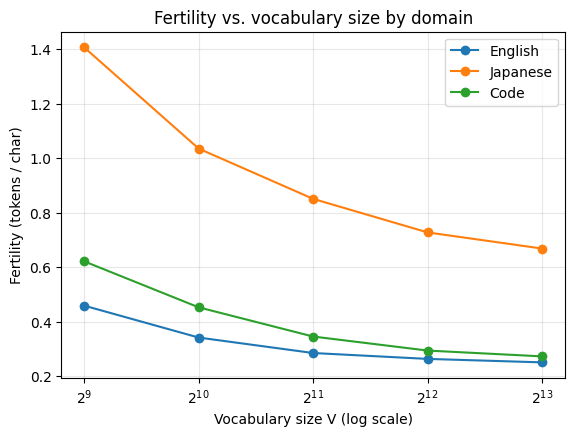

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for domain, results in experiment2_results.items():
    vocab_sizes = sorted(results.keys())
    fertilities = [results[v][1] for v in vocab_sizes]
    ax.plot(vocab_sizes, fertilities, marker="o", label=domain)
ax.set_xscale("log", base=2)
ax.set_xlabel("Vocabulary size V (log scale)")
ax.set_ylabel("Fertility (tokens / char)")
ax.set_title("Fertility vs. vocabulary size by domain")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [10]:
# 実験2の判定: 語彙サイズを2倍にしたときの fertility 減少幅が単調に縮小するか
for domain, results in experiment2_results.items():
    vocab_sizes = sorted(results.keys())
    fertilities = [results[v][1] for v in vocab_sizes]
    deltas = [fertilities[i] - fertilities[i + 1] for i in range(len(fertilities) - 1)]
    monotonic = all(deltas[i] >= deltas[i + 1] for i in range(len(deltas) - 1))
    print(f"{domain:>8}: fertility={[f'{f:.4f}' for f in fertilities]}")
    print(f"{'':>8}  減少幅={[f'{d:.4f}' for d in deltas]}  単調縮小={monotonic}")

 English: fertility=['0.4586', '0.3415', '0.2847', '0.2631', '0.2503']
          減少幅=['0.1171', '0.0568', '0.0216', '0.0127']  単調縮小=True
Japanese: fertility=['1.4069', '1.0352', '0.8507', '0.7275', '0.6682']
          減少幅=['0.3717', '0.1845', '0.1232', '0.0593']  単調縮小=True
    Code: fertility=['0.6213', '0.4524', '0.3452', '0.2937', '0.2723']
          減少幅=['0.1689', '0.1072', '0.0515', '0.0213']  単調縮小=True


### 実験3: 初期語彙方式と未知語

学習コーパスに存在しない文字(絵文字、稀な漢字など)を含むホールドアウト文字列を用意し、`byte_level`の真偽で未知語率を比較する。

**検証すること**: バイトレベル初期語彙は未知語を原理的に発生させない。

**判定基準**: バイトレベルで未知語率が厳密に 0、文字レベル初期語彙で厳密に正。

In [11]:
# 実験3: 未知語(Out-of-Vocabulary)の検証
# 学習コーパス(日本語ドメイン)に存在しない文字(絵文字・極めて稀な漢字)を含む文字列を用意する。
# 日本語コーパスは Wikipedia から取得するため内容が変わりうる。固定の候補文字が
# 偶然コーパスに出現していても実験全体が停止しないよう、候補プールから学習コーパスに
# 存在しない文字だけを動的に選ぶ(文中の一般的な単語は当然コーパスにも出現するため、
# 「学習コーパスに存在しない」ことを検証するのは絵文字・稀な漢字の部分のみに限定する)。
candidate_pool = "😀🎉🚀🌸龘齉靐彟龗鱻麤鸞爨癵驫"
truly_novel_chars = "".join(ch for ch in candidate_pool if ch not in train_texts["Japanese"])
assert len(truly_novel_chars) >= 4, "学習コーパスに存在しない文字が十分に確保できない"
novel_chars_text = f"これは{truly_novel_chars}絶対に出現しない文字列だ。"
print(f"検証に使う未出現文字: {truly_novel_chars}")

char_level_tokenizer = learn_bpe(
    train_texts["Japanese"], vocab_size=2048, byte_level=False, chunk_split_mode="whitespace"
)
byte_level_tokenizer = bpe_tokenizers[("Japanese", 2048)]  # 実験2で学習済み

char_tokens = char_level_tokenizer.encode(novel_chars_text)
byte_tokens = byte_level_tokenizer.encode(novel_chars_text)

char_unk_rate = compute_unknown_rate(char_tokens)
byte_unk_rate = compute_unknown_rate(byte_tokens)

print(f"文字レベル初期語彙: 未知語率={char_unk_rate:.3f}  トークン例={char_tokens[:12]}")
print(f"バイトレベル初期語彙: 未知語率={byte_unk_rate:.3f}  トークン数={len(byte_tokens)}")
print(
    f"実験3判定: バイトレベル未知語率==0 -> {byte_unk_rate == 0.0}, "
    f"文字レベル未知語率>0 -> {char_unk_rate > 0.0}"
)

検証に使う未出現文字: 😀🎉🚀🌸龘齉靐彟龗鱻麤鸞爨癵驫
文字レベル初期語彙: 未知語率=0.536  トークン例=['これは', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>', '<unk>']
バイトレベル初期語彙: 未知語率=0.000  トークン数=60
実験3判定: バイトレベル未知語率==0 -> True, 文字レベル未知語率>0 -> True


### 実験4: 初期語彙方式と語彙サイズの相互作用(日本語)

3.3 節で述べた通り、日本語のユニーク文字数は目標語彙サイズ(512 や 1024 など)を上回りうる。この場合、文字レベル初期語彙は最初からその文字数だけで目標語彙サイズを超えてしまい、**マージが一切発生しない**(`achieved vocab`が学習コーパスのユニーク文字数とほぼ一致し、目標語彙サイズを上回る)。この区間でバイトレベルと文字レベルを比較すると、両者は **異なる語彙予算での比較** になり(バイトレベルは要求どおりの語彙サイズで学習される一方、文字レベルはそれより大きい実効語彙サイズで学習される)、「バイトレベルが不利なのは UTF-8 の 3 バイト表現のコストゆえか、単に語彙予算が違うからか」を分離できない。

そこで、実験2 と同じ`VOCAB_SIZES`(512, 1024, 2048, 4096, 8192)で **日本語ドメインの文字レベル BPE を掃引** し、実験2 で得た日本語のバイトレベル fertility 曲線と重ね描きする。語彙サイズを掃引することで、文字レベルの`achieved vocab`が要求値と一致し始める点(= ユニーク文字数を超え、マージが発生し始める点)を境に、比較可能な区間とそうでない区間を視覚的に区別する。

**検証すること**: バイトレベル初期語彙と文字レベル初期語彙のどちらが日本語で有利かは、語彙サイズに依存する。

**判定基準**: 語彙サイズを掃引したとき、日本語の fertility の大小関係(バイトレベル 対 文字レベル)が語彙サイズによって入れ替わる区間が存在するか。入れ替わりが観測されれば「どちらが優れているか」は語彙サイズに依存するトレードオフであり、全域で一方が有利であればその旨をそのまま報告する。

マージが発生しない区間(文字レベルの`achieved vocab`が要求語彙サイズを上回っている区間)の比較は、語彙予算・その使われ方のいずれも揃っておらず、UTF-8 の 3 バイト表現のコストの有無を分離できないため **解釈不能** である。要求語彙サイズがユニーク文字数を上回り、両者ともマージ予算を持つ比較可能な区間で初めて、トレードオフの検証として意味を持つ。**「A は B より優れている」という形ではなく、どのようなトレードオフが生じるかを説明する形で 7 節の考察を書く。**

**fertility 比較の測定上の非対称性についての注記**: fertility による比較には測定上の非対称性がある。文字レベル初期語彙は、ホールドアウトに学習コーパス未出現の文字が含まれていても、それを未知語(Out-of-Vocabulary)トークン **1 個** として出力する(実験3 参照)。一方バイトレベル初期語彙は未知語を発生させないため(実験3)、同じ文字を UTF-8 の 2〜3 バイト分のトークンで表現する。つまり文字レベルは「表現できない文字」を最も安いコストで処理していることになり、その分だけ fertility が構造的に有利に出うる。**この偏りの大きさを評価するため、以下のセルでは語彙サイズごとに文字レベルのホールドアウト未知語率も測定する**(判定基準はここまでに述べたものから変更しない)。未知語率が無視できる大きさであれば fertility の比較はそのまま解釈でき、無視できない大きさであればその分を割り引いて解釈する必要がある。

**未知語を除去した対照条件について**: 未知語率の測定だけでは、それが fertility の差にどれだけ寄与しているかは分からない。そこで、文字レベルの語彙に単一文字として含まれない文字をホールドアウトから除去した対照条件でも fertility を測定する。この条件では文字レベルは未知語を出さないため、バイトレベルとの差は未知語の扱いに起因しない、符号化効率そのものの差になる。元のホールドアウトでの差(バイトレベル − 文字レベル)が、この対照条件での差と比べて大きい場合、その差分は未知語の扱いに起因する見かけのものであることになる。**この対照比較も判定基準を変更するものではなく、判定結果を機構レベルで説明するための追加測定である。**

**語彙予算の配分についての注記**: バイトレベル初期語彙は 256 バイトから出発するため、UTF-8 で 3 バイトを占める日本語の文字を単一トークンにするには、1 文字あたり 2 回のマージを要する(3.3 節)。したがって、バイトレベルの語彙の相当部分は **文字の再構成** に費やされており、真の部分語(subword)の学習に使える予算はその分少なくなる。この予算配分を直接測定するため、以下のセルでは各語彙サイズにおけるバイトレベル語彙の文字被覆率(学習コーパスのユニーク文字のうち、単一トークンとして表現できるものの割合)と、文字の再構成に費やされたマージ回数の概算を診断量として測定する。**この診断量も判定基準の一部ではなく、判定結果を機構として説明するためのものである。**

In [12]:
# 実験4: 日本語ドメインで文字レベル BPE を実験2 と同じ語彙サイズで掃引する。
# achieved_vocab・fertility に加え、ホールドアウトの未知語率も記録する
# (文字レベル初期語彙が未知語を 1 トークンで処理することによる fertility への
# 影響を評価するため。上の宣言セルの「測定上の非対称性についての注記」を参照)。
#
# 対照条件: 文字レベルの語彙に単一文字として含まれない文字をホールドアウトから
# 除去した文字列でも、文字レベル・バイトレベル(実験2で学習済み)の両方で
# fertility を測定する。この条件では文字レベルは未知語を出さないため、両者の差は
# 未知語の扱いに起因しない、符号化効率そのものの差になる
# (宣言セルの「未知語を除去した対照条件について」を参照)。
#
# ASCII 文字はバイトレベル初期語彙の基底シンボル(256 バイト)にそのまま含まれる
# ため、マージなしで常に被覆される。学習コーパスに出現する ASCII 文字の集合は
# 語彙サイズによらず一定であり、これを基準に「非 ASCII 文字の被覆数」を
# 逆算できる(宣言セルの「予算配分」についての注記を参照)。
japanese_train_ascii_chars = {ch for ch in set(train_texts["Japanese"]) if ord(ch) < 128}

experiment4_results: dict[int, tuple[int, float, float]] = {}
# {requested_vocab_size: (achieved_vocab_size, fertility, unknown_rate)}
experiment4_unk_removed_results: dict[int, tuple[int, float, float]] = {}
# {requested_vocab_size: (removed_char_count, char_fertility_filtered, byte_fertility_filtered)}
experiment4_coverage_results: dict[int, tuple[int, int, float, int, float]] = {}
# {requested_vocab_size: (num_covered, num_total, coverage,
#                          estimated_reconstruction_merges, reconstruction_merge_share)}
holdout = holdout_texts["Japanese"]
for vocab_size in VOCAB_SIZES:
    tokenizer = learn_bpe(
        train_texts["Japanese"],
        vocab_size=vocab_size,
        byte_level=False,
        chunk_split_mode="whitespace",
    )
    byte_tokenizer = bpe_tokenizers[("Japanese", vocab_size)]  # 実験2で学習済み

    tokens = tokenizer.encode(holdout)
    fertility = compute_fertility(len(tokens), len(holdout))
    unknown_rate = compute_unknown_rate(tokens)
    experiment4_results[vocab_size] = (len(tokenizer.vocab), fertility, unknown_rate)
    print(
        f"requested={vocab_size:5d} achieved={len(tokenizer.vocab):5d} "
        f"fertility={fertility:.4f}  未知語率={unknown_rate:.4f}"
    )

    # 文字被覆率(バイトレベル)。ASCII 文字は常に被覆されるため、非 ASCII 文字の
    # 被覆数は「被覆数 - 学習コーパス中の ASCII 文字数」で概算できる。
    # 非 ASCII 文字(UTF-8 で 3 バイト)は 1 文字あたり 2 回のマージを要するという
    # 近似で、文字の再構成に費やされたマージ回数の下限を見積もる(概算であることに
    # 注意。実際にはマージがちょうど同じ文字の3バイトだけを対象に進むとは限らない)。
    num_covered, num_total, coverage = compute_character_coverage(
        byte_tokenizer.vocab, train_texts["Japanese"]
    )
    num_nonascii_covered = num_covered - len(japanese_train_ascii_chars)
    estimated_reconstruction_merges = 2 * num_nonascii_covered
    total_merges = len(byte_tokenizer.vocab) - 256
    reconstruction_merge_share = estimated_reconstruction_merges / total_merges
    experiment4_coverage_results[vocab_size] = (
        num_covered,
        num_total,
        coverage,
        estimated_reconstruction_merges,
        reconstruction_merge_share,
    )
    print(
        f"  [文字被覆率(バイトレベル)] {num_covered}/{num_total}={coverage:.1%}  "
        f"再構成に費やしたマージ回数(概算)={estimated_reconstruction_merges}"
        f"/{total_merges}(総マージ回数の {reconstruction_merge_share:.1%})"
    )

    # 対照: 文字レベルの被覆率(常に 1.0 になるはず。バイトレベルだけが
    # 負っているコストであることを示す対照として出力する)。
    char_num_covered, char_num_total, char_coverage = compute_character_coverage(
        tokenizer.vocab, train_texts["Japanese"]
    )
    print(
        f"  [文字被覆率(文字レベル、対照)] {char_num_covered}/{char_num_total}={char_coverage:.1%}"
    )

    filtered_holdout = "".join(ch for ch in holdout if ch in tokenizer.vocab)
    removed_char_count = len(holdout) - len(filtered_holdout)
    char_fertility_filtered = compute_fertility(
        len(tokenizer.encode(filtered_holdout)), len(filtered_holdout)
    )
    byte_fertility_filtered = compute_fertility(
        len(byte_tokenizer.encode(filtered_holdout)), len(filtered_holdout)
    )
    experiment4_unk_removed_results[vocab_size] = (
        removed_char_count,
        char_fertility_filtered,
        byte_fertility_filtered,
    )
    print(
        f"  [未知語除去後] 除去文字数={removed_char_count}  "
        f"char fertility={char_fertility_filtered:.4f}  "
        f"byte fertility={byte_fertility_filtered:.4f}  "
        f"差={byte_fertility_filtered - char_fertility_filtered:.4f}"
    )

requested=  512 achieved= 1715 fertility=1.0000  未知語率=0.0175
  [文字被覆率(バイトレベル)] 188/1715=11.0%  再構成に費やしたマージ回数(概算)=236/256(総マージ回数の 92.2%)
  [文字被覆率(文字レベル、対照)] 1715/1715=100.0%
  [未知語除去後] 除去文字数=262  char fertility=1.0000  byte fertility=1.3862  差=0.3862
requested= 1024 achieved= 1715 fertility=1.0000  未知語率=0.0175
  [文字被覆率(バイトレベル)] 438/1715=25.5%  再構成に費やしたマージ回数(概算)=736/768(総マージ回数の 95.8%)
  [文字被覆率(文字レベル、対照)] 1715/1715=100.0%
  [未知語除去後] 除去文字数=262  char fertility=1.0000  byte fertility=1.0137  差=0.0137
requested= 2048 achieved= 2048 fertility=0.8167  未知語率=0.0214
  [文字被覆率(バイトレベル)] 764/1715=44.5%  再構成に費やしたマージ回数(概算)=1388/1792(総マージ回数の 77.5%)
  [文字被覆率(文字レベル、対照)] 1715/1715=100.0%
  [未知語除去後] 除去文字数=262  char fertility=0.8133  byte fertility=0.8286  差=0.0153
requested= 4096 achieved= 4096 fertility=0.6742  未知語率=0.0259
  [文字被覆率(バイトレベル)] 1026/1715=59.8%  再構成に費やしたマージ回数(概算)=1912/3840(総マージ回数の 49.8%)
  [文字被覆率(文字レベル、対照)] 1715/1715=100.0%
  [未知語除去後] 除去文字数=262  char fertility=0.6683  byte fertility=0.7043  差=0.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38500 (\N{CJK UNIFIED IDEOGRAPH-9664}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  fig.canvas

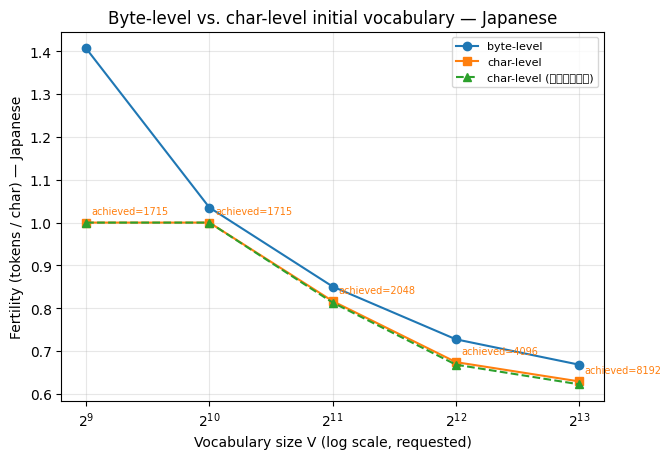

In [13]:
# 実験2 で得た日本語のバイトレベル曲線、実験4 の文字レベル曲線(元のホールドアウト)、
# および文字レベル・未知語除去後の曲線を重ね描きする。
# 文字レベル側(元のホールドアウト)は achieved vocab を注釈として付け、要求値と
# 乖離している点(= マージが発生していない点)を区別できるようにする。
byte_vocab_sizes = sorted(experiment2_results["Japanese"].keys())
byte_fertilities = [experiment2_results["Japanese"][v][1] for v in byte_vocab_sizes]

char_vocab_sizes = sorted(experiment4_results.keys())
char_fertilities = [experiment4_results[v][1] for v in char_vocab_sizes]
char_achieved = [experiment4_results[v][0] for v in char_vocab_sizes]
char_unknown_rates = [experiment4_results[v][2] for v in char_vocab_sizes]
char_filtered_fertilities = [experiment4_unk_removed_results[v][1] for v in char_vocab_sizes]

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(byte_vocab_sizes, byte_fertilities, marker="o", label="byte-level", color="tab:blue")
ax.plot(char_vocab_sizes, char_fertilities, marker="s", label="char-level", color="tab:orange")
ax.plot(
    char_vocab_sizes,
    char_filtered_fertilities,
    marker="^",
    linestyle="--",
    label="char-level (未知語除去後)",
    color="tab:green",
)
for v, f, a in zip(char_vocab_sizes, char_fertilities, char_achieved, strict=True):
    ax.annotate(
        f"achieved={a}",
        (v, f),
        fontsize=7,
        color="tab:orange",
        textcoords="offset points",
        xytext=(4, 6),
    )
ax.set_xscale("log", base=2)
ax.set_xlabel("Vocabulary size V (log scale, requested)")
ax.set_ylabel("Fertility (tokens / char) — Japanese")
ax.set_title("Byte-level vs. char-level initial vocabulary — Japanese")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()

In [14]:
# 実験4の判定: achieved vocab が要求値と一致し始める語彙サイズ(マージが発生し始める点)、
# および fertility の大小関係(バイトレベル対文字レベル)が入れ替わる区間の有無
print("要求値 vs 実効値(achieved vocab):")
for v, a in zip(char_vocab_sizes, char_achieved, strict=True):
    if a == v:
        status = "要求値と一致(マージが発生し、比較可能な区間)"
    else:
        status = f"要求値を超過(マージ 0 回、コーパスのユニーク文字数 = {a}、比較不能な区間)"
    print(f"  requested={v:5d}  achieved={a:5d}  {status}")

print()
byte_gt_char = [b > c for b, c in zip(byte_fertilities, char_fertilities, strict=True)]
print("語彙サイズ:", char_vocab_sizes)
print("fertility: byte > char ->", byte_gt_char)

crossings = [i for i in range(len(byte_gt_char) - 1) if byte_gt_char[i] != byte_gt_char[i + 1]]
if crossings:
    for i in crossings:
        print(
            f"入れ替わりを検出: 語彙サイズ {char_vocab_sizes[i]} と {char_vocab_sizes[i + 1]} の間"
        )
elif all(byte_gt_char):
    print("入れ替わりなし。全域で文字レベルが有利(fertility が小さい)。")
elif not any(byte_gt_char):
    print("入れ替わりなし。全域でバイトレベルが有利(fertility が小さい)。")
else:
    print("byte_gt_char の系列が単調でない(入れ替わりの検出条件を要確認)。")

print()
print("文字レベル初期語彙のホールドアウト未知語率(fertility 比較の非対称性の評価用):")
for v, u in zip(char_vocab_sizes, char_unknown_rates, strict=True):
    print(f"  requested={v:5d}  未知語率={u:.4f}")

print()
print("--- 対照比較: 未知語除去の有無による byte-char fertility 差への影響 ---")
print("(差の絶対値だけでなく、その語彙サイズの fertility に対する相対値も併記する)")
for i, v in enumerate(char_vocab_sizes):
    _removed, char_filtered, byte_filtered = experiment4_unk_removed_results[v]
    original_diff = byte_fertilities[i] - char_fertilities[i]
    filtered_diff = byte_filtered - char_filtered
    unk_contribution = original_diff - filtered_diff
    unk_contribution_share = unk_contribution / original_diff

    print(f"  requested={v:5d}")
    print(
        f"    fertility(元のホールドアウト)  char={char_fertilities[i]:.4f}  "
        f"byte={byte_fertilities[i]:.4f}"
    )
    print(
        f"      差={original_diff:.4f}(char fertility 比 {original_diff / char_fertilities[i]:.1%})"
    )
    print(f"    fertility(未知語除去後)  char={char_filtered:.4f}  byte={byte_filtered:.4f}")
    print(f"      差={filtered_diff:.4f}(char fertility 比 {filtered_diff / char_filtered:.1%})")
    print(
        f"    未知語の扱いに起因する見かけの寄与={unk_contribution:.4f}"
        f"(元の差の {unk_contribution_share:.1%})"
    )

要求値 vs 実効値(achieved vocab):
  requested=  512  achieved= 1715  要求値を超過(マージ 0 回、コーパスのユニーク文字数 = 1715、比較不能な区間)
  requested= 1024  achieved= 1715  要求値を超過(マージ 0 回、コーパスのユニーク文字数 = 1715、比較不能な区間)
  requested= 2048  achieved= 2048  要求値と一致(マージが発生し、比較可能な区間)
  requested= 4096  achieved= 4096  要求値と一致(マージが発生し、比較可能な区間)
  requested= 8192  achieved= 8192  要求値と一致(マージが発生し、比較可能な区間)

語彙サイズ: [512, 1024, 2048, 4096, 8192]
fertility: byte > char -> [True, True, True, True, True]
入れ替わりなし。全域で文字レベルが有利(fertility が小さい)。

文字レベル初期語彙のホールドアウト未知語率(fertility 比較の非対称性の評価用):
  requested=  512  未知語率=0.0175
  requested= 1024  未知語率=0.0175
  requested= 2048  未知語率=0.0214
  requested= 4096  未知語率=0.0259
  requested= 8192  未知語率=0.0278

--- 対照比較: 未知語除去の有無による byte-char fertility 差への影響 ---
(差の絶対値だけでなく、その語彙サイズの fertility に対する相対値も併記する)
  requested=  512
    fertility(元のホールドアウト)  char=1.0000  byte=1.4069
      差=0.4069(char fertility 比 40.7%)
    fertility(未知語除去後)  char=1.0000  byte=1.3862
      差=0.3862(char fertility 比 38.6%)
    未知語の扱い

### 実験5: 空白による事前分割のネガティブコントロール

3 ドメイン × `chunk_split_mode` $\in \{$`whitespace`, `none`$\}$(語彙サイズは 2048 に固定)で、チャンク長の分布統計と fertility を比較する。

**検証すること**: 空白による事前分割は言語依存であり、日本語では機能しない。

**判定基準**: `whitespace`時のチャンク長中央値が、日本語で英語・コードの 10 倍以上。かつ英語・コードでは事前分割の有無による fertility 差が小さい(ネガティブコントロール)。**判定基準はこの 2 点から変更しない。**

英語・コードが陰性対照(negative control)として機能していること、すなわち「事前分割の方式を変えても英語・コードの fertility はほとんど変わらない」ことを 7 節の考察で明示する。**5.1 節の修正(空白をチャンク先頭に保持する方式)により、`whitespace`モードのチャンクは空白の文字数を含むようになった。** 以前の実装(空白を破棄する方式)では`none`モードのみが空白の文字数を fertility に含めており、両モードの fertility を同じ基準で比較できていなかった。この修正により、この交絡が解消されているかどうかも合わせて確認する。

**インデントを持つコードについての注記**: 上記の修正により、`whitespace`モードのチャンクは先頭の空白を含むようになった。このため、インデントを持つコードでは、チャンク長が「単語の長さ」ではなく「インデントの深さ」を反映しうる。これは日本語の「語境界の不在」とは異なる要因でチャンク長を押し上げうるということであり、判定基準の前半(チャンク長中央値の比較)がコードで不成立になった場合、それが「事前分割がコードでも機能している(語がある程度の長さを持つ)」ことを意味するのか、単に「インデントが計上されているだけ」なのかを区別する必要がある。判定基準そのものは変えず、先頭の連続空白を除いたチャンク長中央値(`compute_chunk_length_statistics`の`_without_leading_whitespace`系のキー)を診断量として併せて測定し、この区別に使う。

なお、判定基準の前半(チャンク長中央値の比較)と後半(事前分割の有無による fertility 差)は独立した測定である。前半が不成立でも後半(陰性対照としての実質的な機能)が成立していることはありうるため、7 節では **両者を分けて評価する**。

**陰性対照としての証拠力についての注記**: 判定基準の後半は「英語・コードの fertility 差が小さいこと」しか要求していない。しかし陰性対照(negative control)が証拠として機能するためには、対照群(英語・コード)で効果が出ず、処理群(日本語)で効果が出るという **対比** が必要である。日本語の fertility 差が英語・コードと同程度の大きさであれば、この測定は「事前分割の言語依存性」について何の証拠力も持たない(判定基準は形式的に満たされていても、対比が存在しないため)。7 節ではこの対比が実際に成立しているかどうかを評価する。

日本語には空白がほとんどないため、`whitespace`モードは実質的に改行でしか分割されず、`none`モードとほぼ同一の動作になる。この意味で、日本語の fertility 差が小さいことは(仮にそうなったとしても)測定結果というより、この構成上の帰結である可能性がある。

**コードコーパスの非不変性についての注記**: 6 節で述べた通り、コード(`load_code_corpus`)は本コミット時点のリポジトリ内容に依存し、将来のコミットで`src/`が拡張されると内容が変化しうる。判定基準の前半はコードのチャンク長中央値に依存するため、**`src/`の内容が変われば判定が変わりうる**。

In [15]:
CHUNK_VOCAB_SIZE = 2048
experiment5_chunk_stats: dict[str, dict[str, dict]] = {}
experiment5_fertility: dict[str, dict[str, float]] = {}

for domain, train_text in train_texts.items():
    experiment5_chunk_stats[domain] = {}
    experiment5_fertility[domain] = {}
    holdout = holdout_texts[domain]
    for mode in ["whitespace", "none"]:
        chunks = pretokenize(train_text, mode)
        stats = compute_chunk_length_statistics(chunks)
        experiment5_chunk_stats[domain][mode] = stats

        if mode == "whitespace":
            tokenizer = bpe_tokenizers[(domain, CHUNK_VOCAB_SIZE)]  # 実験2で学習済み
        else:
            tokenizer = learn_bpe(
                train_text, vocab_size=CHUNK_VOCAB_SIZE, byte_level=True, chunk_split_mode=mode
            )
        fertility = compute_fertility(len(tokenizer.encode(holdout)), len(holdout))
        experiment5_fertility[domain][mode] = fertility

        print(
            f"{domain:>8} mode={mode:>10} median_chunk_len={stats['median']:6.1f} "
            f"(先頭空白除く={stats['median_without_leading_whitespace']:6.1f})  "
            f"mean={stats['mean']:6.1f}  fertility={fertility:.4f}"
        )

 English mode=whitespace median_chunk_len=   5.0 (先頭空白除く=   4.0)  mean=   5.6  fertility=0.2847
 English mode=      none median_chunk_len=  37.0 (先頭空白除く=  37.0)  mean=  31.3  fertility=0.2981
Japanese mode=whitespace median_chunk_len=  52.0 (先頭空白除く=  50.0)  mean= 102.4  fertility=0.8507
Japanese mode=      none median_chunk_len=  69.5 (先頭空白除く=  69.5)  mean= 116.8  fertility=0.8298
    Code mode=whitespace median_chunk_len=   8.0 (先頭空白除く=   5.0)  mean=  11.1  fertility=0.3452
    Code mode=      none median_chunk_len=  39.0 (先頭空白除く=  32.0)  mean=  38.5  fertility=0.3201


In [16]:
# 実験5の判定(判定基準・判定式は変更しない)
ja_median_ws = experiment5_chunk_stats["Japanese"]["whitespace"]["median"]
en_median_ws = experiment5_chunk_stats["English"]["whitespace"]["median"]
code_median_ws = experiment5_chunk_stats["Code"]["whitespace"]["median"]
print(f"日本語チャンク長中央値(whitespace): {ja_median_ws}")
print(f"英語チャンク長中央値(whitespace): {en_median_ws}")
print(f"コードチャンク長中央値(whitespace): {code_median_ws}")
print(
    f"判定(日本語 >= 英語 x10): {ja_median_ws} >= {en_median_ws} * 10(={en_median_ws * 10}) "
    f"-> {ja_median_ws >= en_median_ws * 10}"
)
print(
    f"判定(日本語 >= コード x10): {ja_median_ws} >= {code_median_ws} * 10(={code_median_ws * 10}) "
    f"-> {ja_median_ws >= code_median_ws * 10}"
)

print()
print("fertility 差(絶対値と、fertility 自体の大きさに対する相対値):")
for domain in ["English", "Japanese", "Code"]:
    ws = experiment5_fertility[domain]["whitespace"]
    none_ = experiment5_fertility[domain]["none"]
    diff = abs(ws - none_)
    relative_diff = diff / ws
    print(
        f"{domain:>8}: whitespace={ws:.4f}  none={none_:.4f}  差={diff:.4f}  "
        f"相対差={relative_diff:.1%}"
    )

print()
print(
    "--- 診断: 先頭の連続空白がチャンク長にどれだけ寄与しているか(判定基準は上のまま変更しない) ---"
)
print(
    "コードの中央値が大きい原因が先頭空白(インデント)であれば、除外後の中央値は英語と同程度になるはずである。"
)
print("日本語の中央値が大きい原因が語境界の不在であれば、除外後もほとんど変わらないはずである。")
for domain in ["English", "Japanese", "Code"]:
    with_ws = experiment5_chunk_stats[domain]["whitespace"]["median"]
    without_ws = experiment5_chunk_stats[domain]["whitespace"]["median_without_leading_whitespace"]
    print(
        f"{domain:>8}: 先頭空白を含む中央値={with_ws:6.1f}  除いた中央値={without_ws:6.1f}  "
        f"差(先頭空白の寄与)={with_ws - without_ws:6.1f}"
    )

日本語チャンク長中央値(whitespace): 52.0
英語チャンク長中央値(whitespace): 5.0
コードチャンク長中央値(whitespace): 8.0
判定(日本語 >= 英語 x10): 52.0 >= 5.0 * 10(=50.0) -> True
判定(日本語 >= コード x10): 52.0 >= 8.0 * 10(=80.0) -> False

fertility 差(絶対値と、fertility 自体の大きさに対する相対値):
 English: whitespace=0.2847  none=0.2981  差=0.0134  相対差=4.7%
Japanese: whitespace=0.8507  none=0.8298  差=0.0209  相対差=2.5%
    Code: whitespace=0.3452  none=0.3201  差=0.0251  相対差=7.3%

--- 診断: 先頭の連続空白がチャンク長にどれだけ寄与しているか(判定基準は上のまま変更しない) ---
コードの中央値が大きい原因が先頭空白(インデント)であれば、除外後の中央値は英語と同程度になるはずである。
日本語の中央値が大きい原因が語境界の不在であれば、除外後もほとんど変わらないはずである。
 English: 先頭空白を含む中央値=   5.0  除いた中央値=   4.0  差(先頭空白の寄与)=   1.0
Japanese: 先頭空白を含む中央値=  52.0  除いた中央値=  50.0  差(先頭空白の寄与)=   2.0
    Code: 先頭空白を含む中央値=   8.0  除いた中央値=   5.0  差(先頭空白の寄与)=   3.0


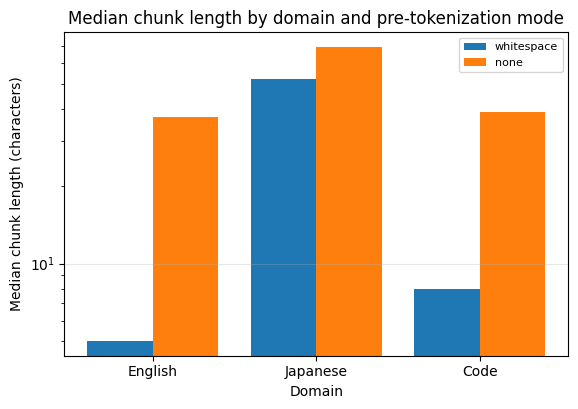

In [17]:
grouped = {
    mode: {domain: experiment5_chunk_stats[domain][mode]["median"] for domain in train_texts}
    for mode in ["whitespace", "none"]
}
plot_grouped_bar(
    grouped,
    title="Median chunk length by domain and pre-tokenization mode",
    ylabel="Median chunk length (characters)",
    xlabel="Domain",
    log_scale=True,
)
plt.show()

### 実験6: スクラッチ Viterbi 分割の検証と BPE との比較

1. 日本語・英語の数十文について、`viterbi_segment`による分割が sentencepiece 自身の分割と完全一致することを確認する。
2. 同一コーパス・同一語彙サイズで BPE と Unigram 言語モデルの分割を比較し、一致率を測る。
3. 不一致箇所の具体例をいくつか表示し、定性的な傾向を読み取る。

**検証すること**: Unigram 言語モデルは BPE と体系的に異なる分割を与える。

**判定基準**: トークン境界の Jaccard 係数(`compute_segmentation_agreement_rate`)の平均が 1.0 未満であり、かつ一致率が低い文に定性的な傾向(どのような箇所で分割が分かれるか)が読み取れる。

**なぜ完全一致率ではなく境界の Jaccard 係数か**: 5.1 節の修正により、自作 BPE(`chunk_split_mode="whitespace"`)も SentencePiece と同様に空白を保持した可逆な符号化になった。したがって両者の符号化の慣習の違いは、もはや「空白を保持するかどうか」ではなく、**空白をどう表現するか**(SentencePiece は`▁`という専用記号に置き換える、自作 BPE は半角空白のまま扱う)という表層形の違いだけになる。この違いだけでも、文単位の完全一致(`compute_exact_match_rate`)を使うと、分割の大部分が同じ位置で切れていても表層形の流儀の違いだけで一致率が 0 に張り付いてしまい、一致の度合いを測れない。境界位置集合の Jaccard 係数を使うことで、部分的な一致の度合いを連続値として評価する。

**語彙サイズについての注記**: sentencepiece の Unigram 言語モデル学習は、語彙サイズが学習コーパスの文字種数(日本語)や、コーパスから抽出できる候補部分文字列数の上限(英語)を外れるとエラーになる。両ドメインで学習可能な語彙サイズとして 2048 を用いる(実験2・実験5と共通)。

**BPE との比較における`byte_level`についての注記**: 実験6-2 で BPE と Unigram 言語モデルを比較する際は、BPE を`byte_level=False`(文字レベル初期語彙)で学習し直す。バイトレベル BPE の部分語は UTF-8 バイトの表現であり、sentencepiece の Unicode 部分語とは構成上表層形が一致しえないため、同一の表現形式(Unicode 文字)で比較する必要がある。

**Viterbi 分割の文字カバレッジについての注記**: sentencepiece は既定で`character_coverage`を 100% 未満(まれな文字を除外)に設定するため、学習語彙が 1 文字も持たない文字を含む文はそもそも分割できない(自作の`viterbi_segment`は未知語へのフォールバックを持たない、3.5 節)。この検証では、学習語彙が単一文字として持つ文字のみからなるホールドアウト文を対象に選ぶ。

In [18]:
UNIGRAM_VOCAB_SIZE = 2048

unigram_tokenizers = {}
for domain in ["English", "Japanese"]:
    t0 = time.time()
    unigram_tokenizers[domain] = train_unigram_model(
        train_texts[domain], vocab_size=UNIGRAM_VOCAB_SIZE, model_prefix=CACHE_DIR / f"spm_{domain}"
    )
    vocab_n = len(unigram_tokenizers[domain].vocab)
    print(f"{domain}: Unigram 言語モデルの学習完了({time.time() - t0:.1f}s, 語彙数={vocab_n})")

English: Unigram 言語モデルの学習完了(0.1s, 語彙数=2047)
Japanese: Unigram 言語モデルの学習完了(0.5s, 語彙数=2047)


In [19]:
# 1. Viterbi 分割と sentencepiece 自身の分割の一致率
# candidates/covered が想定外に少ない(0 件を含む)場合でもノートブック全体が
# 停止しないよう、対象文が確保できないドメインはスキップし、後続セルが参照する
# 変数には安全な既定値(空リスト・NaN)を入れておく。
viterbi_validation = {}
for domain in ["English", "Japanese"]:
    uni = unigram_tokenizers[domain]
    single_chars = {p for p in uni.vocab if len(p) == 1}

    candidates = [s for s in holdout_texts[domain].split("\n") if s.strip()]
    covered = [s for s in candidates if all(ch in single_chars for ch in uni.normalize(s))]
    sentences = covered[:30]

    if not sentences:
        print(
            f"{domain}: 検証対象の文が確保できなかった"
            f"(候補 {len(candidates)} 文中カバー {len(covered)} 文)。この節はスキップする。"
        )
        viterbi_validation[domain] = (float("nan"), [], [], [], [])
        continue

    library_result = [uni.encode_with_library(s) for s in sentences]
    viterbi_result = [uni.encode_with_viterbi(s) for s in sentences]
    rate, mismatches = compute_exact_match_rate(library_result, viterbi_result)
    viterbi_validation[domain] = (rate, mismatches, sentences, library_result, viterbi_result)

    print(
        f"{domain}: 対象文数={len(sentences)}(候補 {len(candidates)} 文中カバー {len(covered)} 文)"
    )
    print(f"{domain}: Viterbi 一致率={rate:.3f}  不一致件数={len(mismatches)}")
    for i in mismatches[:3]:
        print(f"  不一致例 [{i}]  文={sentences[i]!r}")
        print(f"    sentencepiece: {library_result[i]}")
        print(f"    viterbi_segment: {viterbi_result[i]}")

English: 対象文数=30(候補 485 文中カバー 477 文)
English: Viterbi 一致率=1.000  不一致件数=0
Japanese: 対象文数=30(候補 313 文中カバー 199 文)
Japanese: Viterbi 一致率=1.000  不一致件数=0


**不一致が生じた場合の注記**: 上記セルで不一致件数が 0 でない場合、原因として (a) `character_coverage` により一部の文字が語彙から除外されている、(b) sentencepiece 内部の Viterbi 実装が数値誤差や同点処理で自作実装と異なる経路を選んでいる、のいずれかが考えられる。実行結果を見て、実際にどちらであったかを 7 節で報告する(不一致を考察でごまかさない)。

In [20]:
# 2. 同一語彙サイズでの BPE と Unigram 言語モデルの分割比較
# BPE は byte_level=False(文字レベル初期語彙)で学習し直す。バイトレベル BPE の
# 部分語は UTF-8 バイトの表現であり、sentencepiece の Unicode 部分語とは構成上
# 表層形が一致しえないため、同一の表現形式(Unicode 文字)で比較する。
#
# 5.1 節の修正により自作 BPE も空白を保持するようになったため、両者の違いは
# 空白の表現方法だけになった(sentencepiece は ▁、自作 BPE は半角空白のまま)。
# sentencepiece 側の出力を半角空白表現に変換すれば、連結結果は自作 BPE の
# 連結結果(= 元の文そのもの)と一致するはずである。ただし sentencepiece は
# 文頭に「ダミーの接頭辞」として ▁ を 1 つ余分に付与する(UnigramTokenizer.normalize、
# 3.5 節)ため、これは実際の空白ではなく先頭の 1 文字だけ除去し、残りの ▁ を
# 半角空白に置換する。文の正規化(" ".join(s.split()))は、比較に使う文が
# タブなど半角空白以外の空白文字を含まないようにし、▁ との変換を単純化するために
# 残す(必須ではないが安全側に倒す)。


def _sentencepiece_tokens_to_space_form(tokens):
    tokens = list(tokens)
    if tokens and tokens[0].startswith("▁"):
        tokens[0] = tokens[0][1:]  # 文頭のダミー接頭辞(実際の空白ではない)を除く
    despaced = [t.replace("▁", " ") for t in tokens]
    return [t for t in despaced if t]


bpe_vs_unigram = {}
for domain in ["English", "Japanese"]:
    _, _, sentences, _, _ = viterbi_validation[domain]
    if not sentences:
        print(f"{domain}: 実験6-1 で対象文が確保できなかったため、この節はスキップする。")
        bpe_vs_unigram[domain] = ([], [], [], [])
        continue

    bpe_tok = learn_bpe(
        train_texts[domain],
        vocab_size=UNIGRAM_VOCAB_SIZE,
        byte_level=False,
        chunk_split_mode="whitespace",
    )
    uni = unigram_tokenizers[domain]

    normalized_sentences = [" ".join(s.split()) for s in sentences]
    bpe_result = [bpe_tok.encode(s) for s in normalized_sentences]
    library_result = [
        _sentencepiece_tokens_to_space_form(uni.encode_with_library(s))
        for s in normalized_sentences
    ]

    agreements = [
        compute_segmentation_agreement_rate(b, u)
        for b, u in zip(bpe_result, library_result, strict=True)
    ]
    bpe_vs_unigram[domain] = (agreements, normalized_sentences, bpe_result, library_result)
    print(
        f"{domain}: トークン境界 Jaccard 係数  平均={sum(agreements) / len(agreements):.3f}  "
        f"最小={min(agreements):.3f}  最大={max(agreements):.3f}  (n={len(agreements)})"
    )

English: トークン境界 Jaccard 係数  平均=0.602  最小=0.000  最大=1.000  (n=30)
Japanese: トークン境界 Jaccard 係数  平均=0.820  最小=0.000  最大=1.000  (n=30)


In [21]:
# 3. 一致率(Jaccard 係数)が低い文の具体例
# 係数が低い順(分割の食い違いが大きい順)に並べ替え、上位 4 文を表示する。
for domain in ["English", "Japanese"]:
    agreements, sentences, bpe_result, library_result = bpe_vs_unigram[domain]
    if not agreements:
        print(f"=== {domain}: 対象文なし ===")
        continue
    order = sorted(range(len(agreements)), key=lambda i: agreements[i])
    print(f"=== {domain}(Jaccard 係数 平均={sum(agreements) / len(agreements):.3f}) ===")
    for i in order[:4]:
        print(f"  文: {sentences[i]!r}  (Jaccard 係数={agreements[i]:.3f})")
        print(f"    BPE:     {bpe_result[i]}")
        print(f"    Unigram: {library_result[i]}")
    print()

=== English(Jaccard 係数 平均=0.602) ===
  文: 'CORIOLANUS:'  (Jaccard 係数=0.000)
    BPE:     ['C', 'O', 'RIOLAN', 'US:']
    Unigram: ['CORIOLANUS', ':']
  文: 'CORIOLANUS:'  (Jaccard 係数=0.000)
    BPE:     ['C', 'O', 'RIOLAN', 'US:']
    Unigram: ['CORIOLANUS', ':']
  文: 'appear,'  (Jaccard 係数=0.333)
    BPE:     ['a', 'pp', 'ear', ',']
    Unigram: ['appear', ',']
  文: "man's voice."  (Jaccard 係数=0.333)
    BPE:     ['m', 'an', "'s", ' voic', 'e.']
    Unigram: ['man', "'", 's', ' voice', '.']

=== Japanese(Jaccard 係数 平均=0.820) ===
  文: '地理'  (Jaccard 係数=0.000)
    BPE:     ['地', '理']
    Unigram: ['地理']
  文: '気候'  (Jaccard 係数=0.000)
    BPE:     ['気候']
    Unigram: ['気', '候']
  文: '自治体'  (Jaccard 係数=0.000)
    BPE:     ['自治', '体']
    Unigram: ['自治体']
  文: '自然公園'  (Jaccard 係数=0.667)
    BPE:     ['自', '然', '公', '園']
    Unigram: ['自然', '公', '園']



### 実験7: 語彙サイズと計算量のトレードオフ(理論計算)

実験2で得た fertility から、固定の文字数を処理する際の系列長 $n$ を各語彙サイズについて求め、$d_{\text{model}}$ を固定した仮想的なモデルについて、埋め込み行列のパラメータ数 $V \times d_{\text{model}}$、Attention の演算量 $O(n^2 d_{\text{model}})$、順伝播ネットワークの演算量 $O(n \, d_{\text{model}}^2)$ を算出する(3.7 節)。

**これは実測(実際の実行時間の計測)ではなく、理論式による計算である。** 以下のセルは fertility という実測値を入力に使うが、算出する量そのものは実行時間の計測結果ではない。3 ドメインそれぞれで、埋め込みパラメータ数の増加曲線と系列長由来の演算量の減少曲線がどのあたりで交差するか(相対的な大小関係がどう変わるか)を確認する。

In [22]:
D_MODEL = 768  # 仮想的なモデルの隠れ次元(固定)
TOTAL_CHARS = 1_000_000  # 処理対象として仮定する文字数 C(固定)

experiment7_results = {}
for domain, results in experiment2_results.items():
    vocab_sizes = sorted(results.keys())
    achieved_vocabs = [results[v][0] for v in vocab_sizes]
    fertilities = [results[v][1] for v in vocab_sizes]
    seq_lengths = [f * TOTAL_CHARS for f in fertilities]  # n = fertility x C

    embedding_params = [v * D_MODEL for v in achieved_vocabs]
    attention_flops = [n**2 * D_MODEL for n in seq_lengths]
    ffn_flops = [n * D_MODEL**2 for n in seq_lengths]

    experiment7_results[domain] = {
        "vocab_sizes": vocab_sizes,
        "seq_lengths": seq_lengths,
        "embedding_params": embedding_params,
        "attention_flops": attention_flops,
        "ffn_flops": ffn_flops,
    }
    print(f"=== {domain} ===")
    for i, v in enumerate(vocab_sizes):
        print(
            f"  V={v:5d}  n={seq_lengths[i]:9.0f}  embed_params={embedding_params[i]:11,.0f}  "
            f"attn_flops={attention_flops[i]:.3e}  ffn_flops={ffn_flops[i]:.3e}"
        )

=== English ===
  V=  512  n=   458600  embed_params=    393,216  attn_flops=1.615e+14  ffn_flops=2.705e+11
  V= 1024  n=   341467  embed_params=    786,432  attn_flops=8.955e+13  ffn_flops=2.014e+11
  V= 2048  n=   284667  embed_params=  1,572,864  attn_flops=6.223e+13  ffn_flops=1.679e+11
  V= 4096  n=   263067  embed_params=  3,145,728  attn_flops=5.315e+13  ffn_flops=1.552e+11
  V= 8192  n=   250333  embed_params=  5,033,472  attn_flops=4.813e+13  ffn_flops=1.477e+11
=== Japanese ===
  V=  512  n=  1406867  embed_params=    393,216  attn_flops=1.520e+15  ffn_flops=8.298e+11
  V= 1024  n=  1035200  embed_params=    786,432  attn_flops=8.230e+14  ffn_flops=6.106e+11
  V= 2048  n=   850667  embed_params=  1,572,864  attn_flops=5.558e+14  ffn_flops=5.017e+11
  V= 4096  n=   727467  embed_params=  3,145,728  attn_flops=4.064e+14  ffn_flops=4.291e+11
  V= 8192  n=   668200  embed_params=  6,291,456  attn_flops=3.429e+14  ffn_flops=3.941e+11
=== Code ===
  V=  512  n=   621267  embed_para

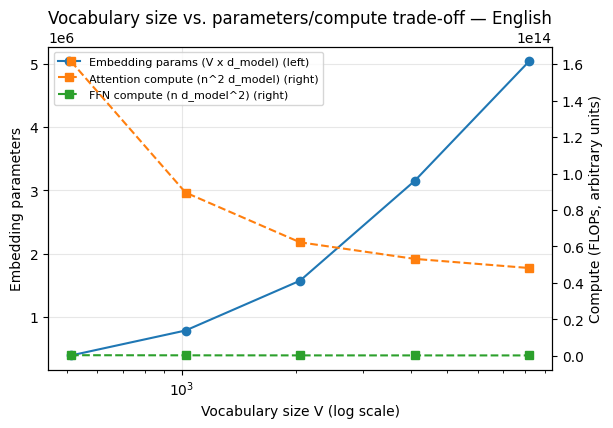

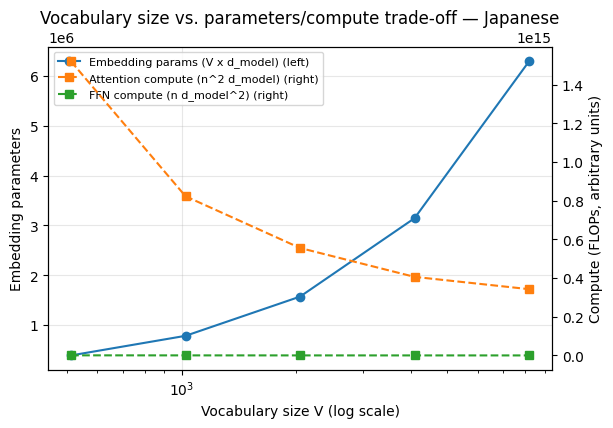

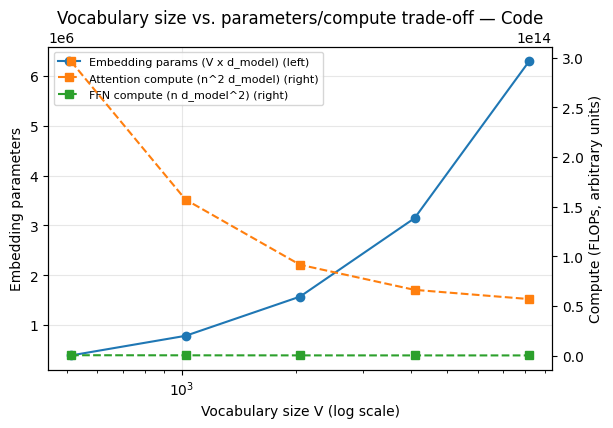

In [23]:
for domain, r in experiment7_results.items():
    plot_dual_axis_curves(
        r["vocab_sizes"],
        left_curves={"Embedding params (V x d_model)": r["embedding_params"]},
        right_curves={
            "Attention compute (n^2 d_model)": r["attention_flops"],
            "FFN compute (n d_model^2)": r["ffn_flops"],
        },
        xlabel="Vocabulary size V (log scale)",
        left_ylabel="Embedding parameters",
        right_ylabel="Compute (FLOPs, arbitrary units)",
        title=f"Vocabulary size vs. parameters/compute trade-off — {domain}",
        log_x=True,
    )
    plt.show()

## 7. 結果・考察 / Results and Discussion

**注記**: 本ノートブックは Google Colab での実行前の状態でコミットされている。以下の各項目は、実行後に得られるセル出力(マージ規則の実例、fertility の数値、一致率、判定結果の真偽など)と付き合わせて、この Markdown セルを更新すること(CLAUDE.md「実行環境を変更してノートブックを再実行した場合」の方針と同じ理由による)。判定基準を満たさなかった実験があれば、結論を曲げずにそのまま報告する。

**事前宣言した結論と事後的な解釈の区別についての注記**: 更新の際は、**実験ごとに事前宣言した判定基準による結論** と、**データを見た後に得られた事後的な解釈**(例: 実験5 の「事後的な観察」)を、節または段落として明確に分けて記述すること。後者を前者に格上げしない(事後的な解釈を、あたかも事前に検証を計画していたかのような書き方にしない)。

### 実験1(BPE のマージ過程)

- [ ] マージ規則の前半が高頻度の 2 文字組、後半にかけて単語・接尾辞相当のシンボルに近づく傾向が実際に観察されたか。

### 実験2(語彙サイズと fertility の関係)

- [ ] 3 ドメインそれぞれの fertility 曲線(語彙サイズ対数軸)の形状。
- [ ] 語彙サイズを 2 倍にしたときの fertility 減少幅が全区間で単調に縮小したか(ドメインごとに判定)。
- [ ] 英語ドメインで学習コーパスから作れるユニークなペアが尽き、目標語彙サイズより小さい`achieved`語彙サイズで学習が終了する事象が発生したか。発生した場合、それが fertility 曲線の解釈にどう影響するか。

### 実験3(初期語彙方式と未知語)

- [ ] バイトレベル未知語率が厳密に 0、文字レベル未知語率が正であったか。

### 実験4(初期語彙方式と語彙サイズの相互作用、日本語)

- [ ] 文字レベルの`achieved vocab`が要求語彙サイズと一致し始める語彙サイズはどこか(= ユニーク文字数を超える点)。それより下の区間は語彙予算が揃っておらず比較不能であることを明記する。
- [ ] 比較可能な区間(要求語彙サイズがユニーク文字数を上回る区間)で、バイトレベルと文字レベルの fertility の大小関係が入れ替わったか。入れ替わらなかった場合はどちらが一貫して有利だったかを述べる。
- [ ] 未知語を除去した対照条件での差は、元の差と比べてどれだけ縮んだか。**縮小量(見かけの寄与)が語彙サイズによらずほぼ一定であるかを確認する。** 一定であれば、「ホールドアウト中の未知語の絶対数がほぼ一定であり、文字レベルはそれを常に 1 トークンで処理している」という機構と整合しており、宣言セルで事前に述べた機構の説明が独立な測定で裏付けられたことになる。一定でない場合はその旨をそのまま記述する。
- [ ] 未知語除去後も差が正であれば、「文字レベルの優位は未知語の扱いだけでは説明されない」と言える。**ただし主張できるのはそこまでであり、元の差の大きさそのものは未知語の影響を含むため過大である** ことを明記し、元の差のうち何割が未知語の扱いに起因していたかを百分率で述べる。
- [ ] 差の大きさは **絶対値ではなく、fertility 自体に対する百分率で記述する**。絶対値だけでは差の実質的な大きさが読者に伝わらないため。
- [ ] 語彙サイズに対して差(元の差・未知語除去後の差のいずれも)が単調に変化しているかを確認する。**単調でない場合はその旨を明記する**(BPE の学習・符号化は決定的であるため、これはノイズではなく構造的な現象である)。読者が「語彙サイズを上げれば単調に差が縮む」と誤読しないようにする。
- [ ] バイトレベル語彙が学習コーパスのユニーク文字を全種類被覆するのは、どの語彙サイズか。それより小さい語彙サイズでは、バイトレベルは文字の再構成すら完了していないことになる。
- [ ] 文字被覆率がテスト範囲(512〜8192)内で 1.0 に到達しなかった場合、それ自体を明記する。3.3 節では「目標語彙サイズが十分に大きければ、バイトレベル初期化であってもマージによって頻出する日本語文字を 1 トークンに統合しきれる」と述べているが、これは理論上の主張であり、本ノートブックが検証した語彙サイズの範囲内で実際に統合が完了するとは限らない。到達しなかった場合は、日本語のような文字種の多い言語では、文字の再構成コストを解消するために本ノートブックで試した範囲より大きい語彙サイズ(例: GPT-2 が採用する 50,257 [6])が実際には必要になることが示唆される、という形で結論づける。
- [ ] 総マージ回数に占める文字再構成の割合(語彙サイズごとの推移)が、それ自体として単調に変化しているかを確認する。単調でない場合、fertility 差の非単調性(前項参照)と単純な 1 対 1 の対応があるとは限らないことになる。対応が見られない場合は、無理に辻褄を合わせず「両者の非単調性の間に単純な対応関係は見られず、機構としては説明できていない」とそのまま記述する。文字被覆率・予算配分の測定はそれ自体が診断量として意味を持つため、fertility 差を完全に説明できなくても実験4の結論(未知語除去後も文字レベルが有利であること、その優位の一部は語彙予算の使われ方の違いに起因すると推測されること)を損なうものではないことを明記する。
- [ ] 各語彙サイズで、総マージ回数のうち文字の再構成に費やされた割合はどの程度か。語彙サイズが大きくなるにつれてこの割合が下がるかを確認する。
- [ ] **fertility 差が単調でないことを、この予算配分の観点から説明できるか。** 文字の再構成が完了する語彙サイズの前後で差の傾向が変わっているなら、それが 3.3 節で理論として述べた「UTF-8 の 3 バイト表現のコスト」の直接的な裏付けになる。説明がつかない場合は、**無理に説明せず「機構としては説明できていない」と正直に記述する。**
- [ ] 文字レベル初期語彙の被覆率が常に 1.0 であることを対照として示し、このコストがバイトレベル固有のものであることを明記する。
- [ ] 文字レベル初期語彙は、最大の語彙サイズ(8192)でもホールドアウトの一定割合を未知語として失っている。fertility の優劣とは独立に、この非可逆性そのものが実用上のコストであることを述べ、「圧縮効率」と「未知語を出さないこと」のどちらを優先するかというトレードオフの形で結論を書く。**どちらかが優れているという単純化をしない。**
- [ ] 「バイトレベルは常に優れている」「文字レベルは常に優れている」のいずれの単純化も避け、語彙サイズと対象言語の文字分布に依存するトレードオフとして記述する。

### 実験5(空白による事前分割のネガティブコントロール)

**前半(チャンク長中央値)**

- [ ] ドメインごとの成立・不成立と、判定式に代入した実際の数値(日本語の中央値、比較先のドメインの中央値とその 10 倍)を明記する。
- [ ] **閾値(10 倍)からの余裕がどれだけあったか。** 余裕が小さい場合は、閾値の設定次第で判定が変わりうる位置にあることを明記し、頑健な主張は中央値の桁の違いのほうであると述べる。
- [ ] 不成立のドメインがあった場合、先頭空白を除いたチャンク長中央値と対比して、その原因が「語境界の不在」か「先頭空白(インデント)の計上」かを述べる。
- [ ] コードのチャンク長中央値は本コミット時点の`src/`の内容(6 節)に依存する。将来`src/`が拡張されると、この判定は変わりうることを注記する。

**後半(fertility 差)**

- [ ] 英語・コードの fertility 差の大きさ(絶対値・相対値)を述べる。
- [ ] **日本語の差と比較する。** 陰性対照が証拠として機能するには、対照群(英語・コード)で効果が出ず、処理群(日本語)で効果が出るという **対比** が必要である。日本語の差が対照群と同程度、またはそれ以下であれば、判定基準が形式的に満たされていても **当初想定した対比による証拠力は持たない** ことを明記する。「陰性対照として機能した」という書き方をしない。5.1 節の修正(空白をチャンク先頭に保持する方式)により`whitespace`モードの fertility が空白の文字数を反映するようになったことが、この判定にどう影響したか(修正前との比較は本ノートブックの外で確認済みであり、実行結果と付き合わせて記述する)。

**事後的な観察(事前宣言した検証ではないことを明示する)**

- [ ] 3 ドメインの相対差の **順位** に着目した場合に何が読み取れるか。この相対差が測っているのは「空白による事前分割がその言語で実際に何かをしているか」であり、日本語で最小であることは、日本語には分割すべき空白がほとんどなく`whitespace`モードが実質的に`none`モードと同じ動作になることと整合する。すなわち、事前に想定したのとは **逆向きに** 同じ結論(事前分割は日本語では機能しない)を支持する結果になりうる。
- [ ] **上記が事後的な解釈であり、事前宣言した判定基準による検証ではないことを明示的に述べる。** 別のコーパス・別の言語対で改めて確認する余地があることも書く。事後解釈を検証済みの結論として扱わないこと。
- [ ] 3 ドメインすべてで事前分割の方式による fertility 差が小さかった場合、「事前分割は圧縮効率にほとんど寄与しない」という知見として述べ、これが 3.6 節で述べた SentencePiece が事前分割を捨てられる理由の裏付けになることを書く。
- [ ] `none`モードのチャンク長は改行のみで分割した結果(= 1 行の長さ)であり、事前分割の言語依存性とは別の量を測っていることを注記する。
- [ ] コードドメインのチャンク長中央値は本コミット時点の`src/`の内容に依存する(6 節を参照)。将来`src/`が拡張されると、判定基準の前半の成立・不成立が変わりうることを踏まえて結論を書く。

### 実験6(Viterbi 分割の検証・BPE との比較)

- [ ] Viterbi 一致率が英語・日本語のいずれも 100% であったか。100% でなかった場合、不一致件数と原因の推定(character_coverage による文字の除外か、実装上の差異か)。
- [ ] BPE と Unigram 言語モデルのトークン境界 Jaccard 係数(平均・最小・最大)、および係数が低い文に読み取れた定性的な傾向(例: 句読点の分離のしかた、頻出単語の分割単位の違いなど)。Jaccard 係数が 0.0 や 1.0 に張り付いていないか(張り付いている場合は指標か比較設定に問題がある可能性があるため、その旨を報告する)。

### 実験7(語彙サイズと計算量のトレードオフ)

- [ ] 3 ドメインで、埋め込みパラメータ数の増加曲線と系列長由来の演算量の減少曲線の交差する位置(あるいは相対的な大小関係)がどう異なったか。

### 006 への接続

本ノートブックでは、BPE・Unigram 言語モデルという 2 つの部分語分割アルゴリズムと、語彙サイズが圧縮効率・系列長・計算量に与える影響を比較したが、**どの方式・どの語彙サイズを採用するかの選定は行っていない**。006 の小型 GPT の事前学習では、本トピックで得た知見(fertility のドメイン依存性、語彙サイズと計算量のトレードオフ)を踏まえてトークナイザを改めて選定する。